# TorchRTM Quick Start Tutorial
### A high-performance vegetation RTM package with deep learning integration**
**Authors:**  
Peng Sun, Peter van Bodegom, Marco D. Visser

Introduction

This notebook provides a guided introduction to TorchRTM, a GPU-accelerated, differentiable framework for simulating vegetation optical properties from the leaf to the atmosphere. TorchRTM is built to support both traditional radiative-transfer modelling and modern physics-informed machine learning workflows, including PINNs and autoencoder-based inversion strategies.

The tutorial walks through:

- running forward mode simulations with PROSPECT-5D, PROSAIL and SMAC,

- using inverse mode through look-up tables,

- training and evaluating a neural network (PINN) - which in essence means building an autoencoder-style PINN, where physical RTM modules act as differentiable decoders.

Each section includes annotated code so new users can reproduce the results. Experts should be able to adapt the components for large-scale experiments and hybrid modelling pipelines of their own.

We do assume familiarity with both python and pyTorch.


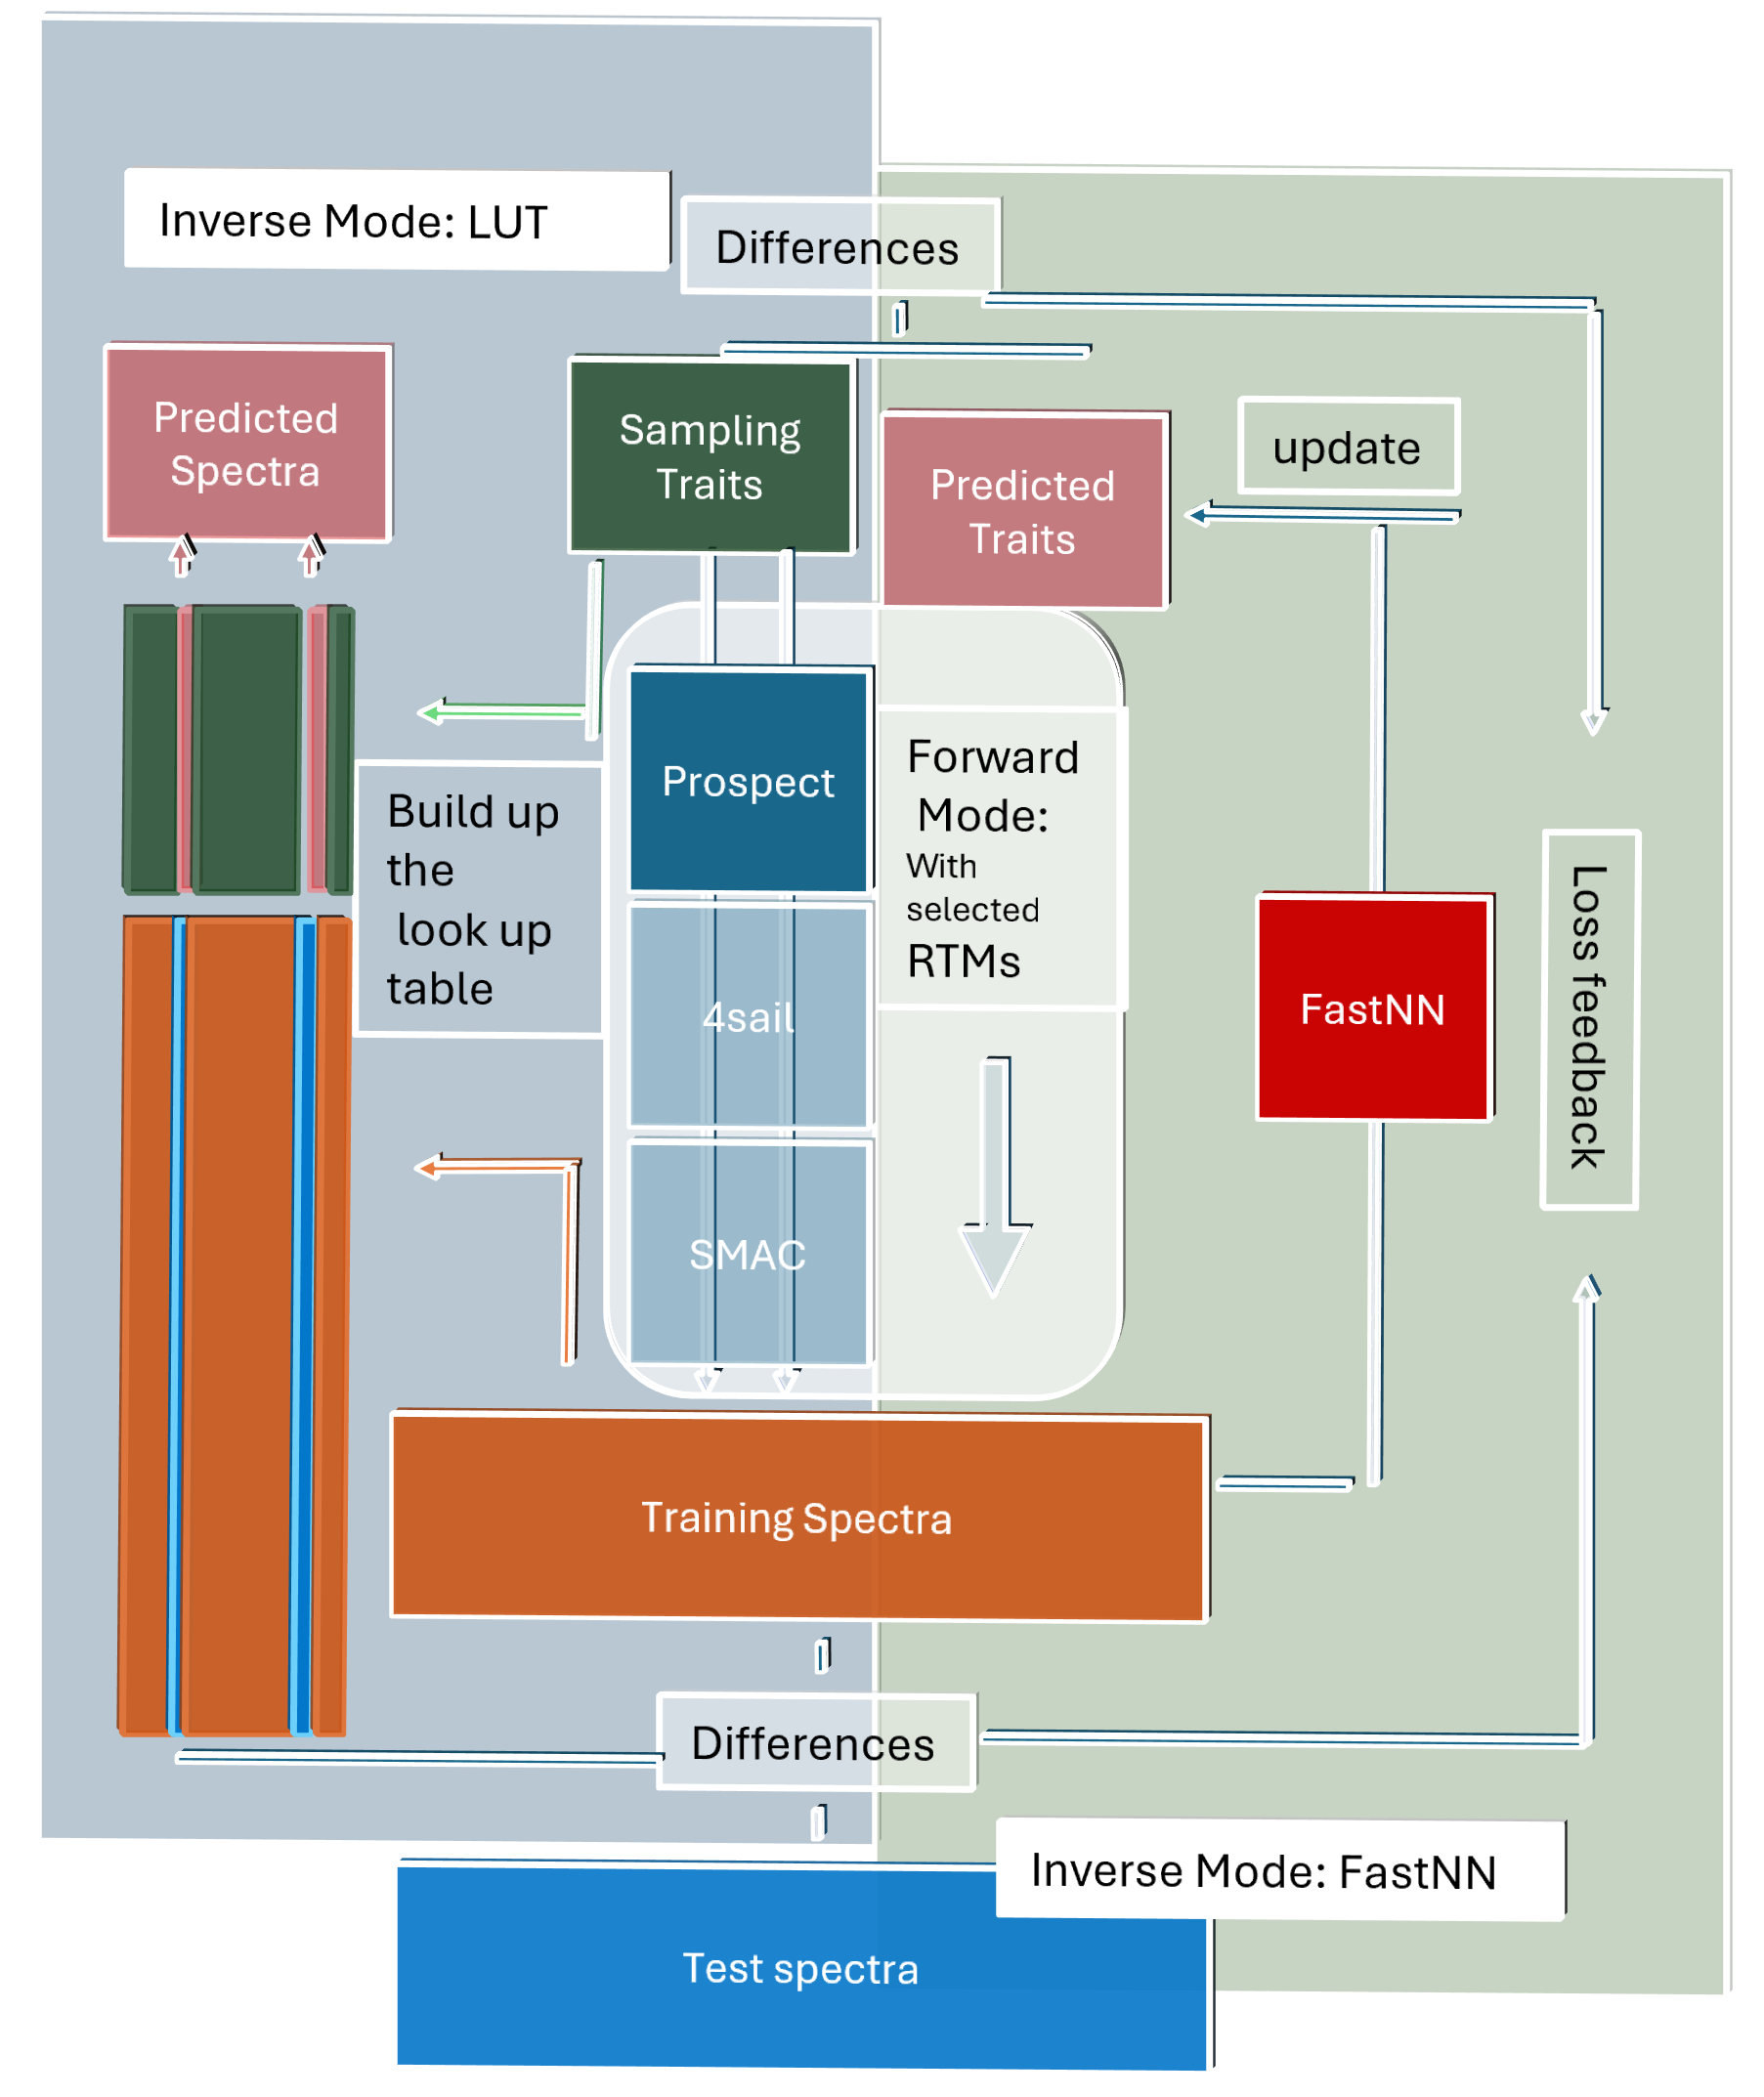

At the time of code testing the system information was:



# Extract GPU Information

Before performing any modelling, we first detect whether GPUs are available. TorchRTM is optimized for GPU acceleration, particularly for large batch simulations and training physics-informed models.

In [1]:
# @title Extract GPU information
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Wed Jan  7 11:16:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Setup dependancies

Below we install TorchRTM (if needed), import required Python libraries, and configure the runtime environment. This establishes all dependencies needed for forward and inverse modelling.

Install torchrtm package

In [1]:
!pip install torchrtm==1.4.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 476.2/476.2 kB 9.3 MB/s eta 0:00:00


# Load Standard and Third-Party Libraries

We load scientific computing libraries (NumPy, SciPy, pandas), visualization tools (matplotlib, seaborn), and PyTorch modules required for differentiability and neural-network inversion.

The following code block also imports all RTM components from the TorchRTM package, including:

- Leaf-level models (PROSPECT-5B and PROSPECT-5D)

- Canopy model PROSAIL

- Atmospheric correction SMAC tools

- Lookup-table and neural-network inversion modules

Load all required packages, set the working directory, and configure the computing device.   

TorchRTM automatically detects CUDA availability with this code below "device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")".


If a GPU is available, all forward and backward simulations will run on GPU, significantly accelerating both modelling and training.



In [2]:
# Standard Libraries
import datetime
import os
import time
import warnings
import random
from math import pi

# Third-Party Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, recall_score
)
from scipy.special import exp1, betainc
from scipy.stats import qmc
import torch
from torch import sin, cos, tan, acos, asin, log, pow, sqrt, square, exp
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.autograd import Variable
import torch.nn.functional as F
import torch.utils.benchmark as benchmark
from tqdm import tqdm

# Custom Modules from torchrtm package
from torchrtm.leaf.prospect import prospect5b, prospectd
from torchrtm.utils.torchlut import Torchlut
from torchrtm.models import prosail
from torchrtm.retrival.fastLUT import Torchlut_pred
from torchrtm.retrival.fastNN import Inverse_Net
from torchrtm.utils.spectradataset import SpectraDataset
from torchrtm.data_loader import load_soil_spectra
from torchrtm.utils.torch_utils import normalize_parameters

# Suppress warnings
warnings.filterwarnings("ignore")
# Configure device for computation
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

dry_soil, wet_soil = load_soil_spectra(device=device)


Above we also load several TorchRTM modules require soil reflectance spectra. These are loaded once and kept on the active device.

### Helper functions

To simplify data handling, we define convenience wrappers for:

- converting NumPy arrays → CUDA tensors,

- converting PyTorch tensors → NumPy arrays,

- setting random seeds for reproducibility.

These functions make the workflow cleaner and ensure consistent behaviour across systems.

In [3]:
def to_cuda(x):
    """Converts data to a CUDA tensor."""
    return torch.tensor(x, dtype=torch.float32).to(device)
def to_np(x):
    """Converts a tensor to a NumPy array."""
    return x.detach().cpu().numpy()
import numpy as np
import random
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)  #
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)


Load the required parameters for the PROSPECT-5, 4SAIL, and SMAC models.  


Set up the random seed

In [4]:
import numpy as np
import random
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)  #
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

Finally, we define a general regression plotting function. This will be used throughout the tutorial to evaluate inversion results produced by lookup tables, neural networks, or autoencoder-based PINNs.

Feel free to skip the code if only interested in torchRTM. It produces:

- scatterplots,

- best-fit lines,

- 1:1 comparison lines,

- metrics such as R², RMSE, and slope,

- and a summary table.

It simply gives some useful immediate, intuitive diagnostic insight into inversion performance.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

def plot_regressions(y_true, y_pred, feature_names=None, xy_same=True):
    """
    Plot regression scatter plots for each feature and output a performance table (r², RMSE, Slope).

    Parameters
    ----------
    y_true, y_pred : array-like or DataFrame
        True and predicted values with the same shape. Each column represents one feature.
    feature_names : list of str, optional
        Custom feature names. If None, use the column names of y_true.
    xy_same : bool, default=True
        If True, force the same x/y limits and draw 1:1 line.
    """
    assert y_true.shape == y_pred.shape, "y_true and y_pred must have the same shape" #, sharex=True, sharey=True

    n_features = y_true.shape[1]
    if feature_names is None:
        feature_names = y_true.columns

    metrics = []

    fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 5), dpi=300)
    if n_features == 1:
        axes = [axes]
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    for i, name in enumerate(feature_names):
        # Remove missing values
        mask = ~(np.isnan(y_true[:, i]) | np.isnan(y_pred[:, i]))
        yt = y_true[:, i][mask]
        yp = y_pred[:, i][mask]

        # Compute r², RMSE, slope
        corr = np.corrcoef(yt, yp)[0, 1]
        r2 = corr ** 2
        rmse = np.sqrt(np.mean((yt - yp) ** 2))
        slope, intercept, _, _, _ = linregress(yt, yp)

        metrics.append({'Feature': name, 'r2': r2, 'RMSE': rmse, 'Slope': slope})

        # Plot scatter
        ax = axes[i]
        ax.scatter(yt, yp, alpha=0.6, edgecolor='k')

        # Regression line
        xline = np.linspace(min(yt.min(), yp.min()), max(yt.max(), yp.max()), 100)
        if xy_same:
            ax.plot(xline, slope * xline + intercept, 'r--', label='Fit')
            ax.plot(xline, xline, 'k-', label='1:1')

        ax.set_title(name, fontsize=20)

        # Remove inner labels
        if i > 0:
            ax.set_ylabel('')
        ax.set_xlabel('' if i < n_features - 1 else 'True')

        # Keep the same range for both axes (optional)
        if xy_same:
            minv = min(yt.min(), yp.min())
            maxv = max(yt.max(), yp.max())
            margin = 0.05 * (maxv - minv)
            minv -= margin
            maxv += margin
            ax.set_xlim(minv, maxv)
            ax.set_ylim(minv, maxv)
            ax.set_aspect('equal', adjustable='box')
            #print(maxv)
        # Text box with metrics
        txt = f"r²={r2:.2f}\nRMSE={rmse:.4f}\nSlope={slope:.2f}"
        ax.text(
            0.95, 0.05, txt,
            ha='right', va='bottom', transform=ax.transAxes,
            fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )

    # Set shared x and y labels only once
    fig.text(0.5, 0.003, 'Observed Values', ha='center', fontsize=24)
    fig.text(0.04, 0.5, 'Predicted Values', va='center', rotation='vertical', fontsize=24)

    plt.tight_layout(rect=[0.06, 0.06, 1, 1])
    plt.show()

    metrics_df = pd.DataFrame(metrics)
    return metrics_df


# Forward mode

## Generate Random Biophysical Parameters for Forward Simulation



In this section, we give an example of how to prepare a set of reasonable biophysical and observational parameters that will serve as inputs to the forward radiative-transfer models. These parameters govern leaf optics, canopy structure, viewing geometry, and atmospheric composition. Generating them programmatically allows us to simulate diverse spectral conditions and test the full TorchRTM pipeline. We refer readers to foundational papers for each RTM for a detailed understanding of these parameters (cited in the maintext).

For demonstration purposes we begin with a batch size of 1, but please do note that all operations are vectorized and can scale efficiently to thousands of samples on GPU when needed.

First, we create a random matrix of parameter values within physically meaningful ranges.

Note that the helper function "normalize_parameters()" rescales values into appropriate domains for the PROSPECT-5D, 4SAIL, and SMAC models.

In [5]:

test_num = 5

# Set up the scale for each parameters
many_paras = torch.rand(test_num,20,dtype = torch.float32).to(device)
real_paras = normalize_parameters(many_paras[:,:-3],fitting = False)
atom_papra = normalize_parameters(many_paras[:,-3:],fitting = False,param_type='atom')


lai = real_paras[:,0]
LIDFa = real_paras[:,1]
LIDFb = real_paras[:,2]
q = real_paras[:,3]
tts = real_paras[:,4]
tto = real_paras[:,5]
psi = real_paras[:,6]
psoil = real_paras[:,7]
N = real_paras[:,8]
Cab = real_paras[:,9]
Car = real_paras[:,10]
Cbrown = real_paras[:,11]
Cw = real_paras[:,12]
Cm = real_paras[:,13]
Canth = real_paras[:,14]
prot = real_paras[:,15]
Cbc = real_paras[:,16]

alpha = torch.tensor(40).to(device).expand([test_num])
tran_alpha = alpha.clone()
aot550 = atom_papra[:,0]
uo3 = atom_papra[:,1]
uh2o = atom_papra[:,2]
traits = torch.stack([Cab,Car,Canth,Cbrown,Cw,Cm],axis = 1)



TorchRTM returns parameters in interpretable units respectining what was used in the orginal models (e.g., Cab in µg/cm², leaf structure parameter N, canopy LAI, solar/observer angles, etc.).

**Note on reproducibility**: Below we reset some parameters to fixed values - to ensure reproducible examples.  This ensures that figures shown in the tutorial match to some extent with what we intended. Obviously, the user is free to use the using random numbers from above instead.

In this section, we demonstrate the use of forward mode to generate simulated spectra in parallel. We will execute the entire **PROSPECT-4SAIL-SMAC** process and visualize the results of each step.

In [6]:
B = 1
traits=torch.tensor([[40.0, 8.0, 0.0, 0.01, 0.008,0.5]] * B).to(device)
N=torch.tensor([1.5] * B).to(device)
LIDFa=torch.tensor([-0.3] * B).to(device)
LIDFb=torch.tensor([-0.1] * B).to(device)
lai=torch.tensor([3.0] * B).to(device)
q=torch.tensor([0.5] * B).to(device)
tts=torch.tensor([30.0] * B).to(device)
tto=torch.tensor([20.0] * B).to(device)
psi=torch.tensor([10.0] * B).to(device)
alpha=torch.tensor([40.0] * B).to(device)

psoil=torch.tensor([0.5] * B).to(device)

## Forward Mode: Simulating Leaf, Canopy, and Atmospheric Reflectance

The forward mode computes spectral reflectance and transmittance layer by layer:

- Leaf optics using PROSPECT-D

- Canopy radiative transfer using 4SAIL

- Atmospheric correction using SMAC to produce TOA reflectance

All modules are differentiable and GPU-accelerated.

### PROSPECT-D: Leaf Reflectance and Transmittance

This produces the characteristic near-infrared plateau and visible chlorophyll absorption features.

In [7]:
rho,tau = prospectd(traits,N, alpha = alpha,print_both = True)


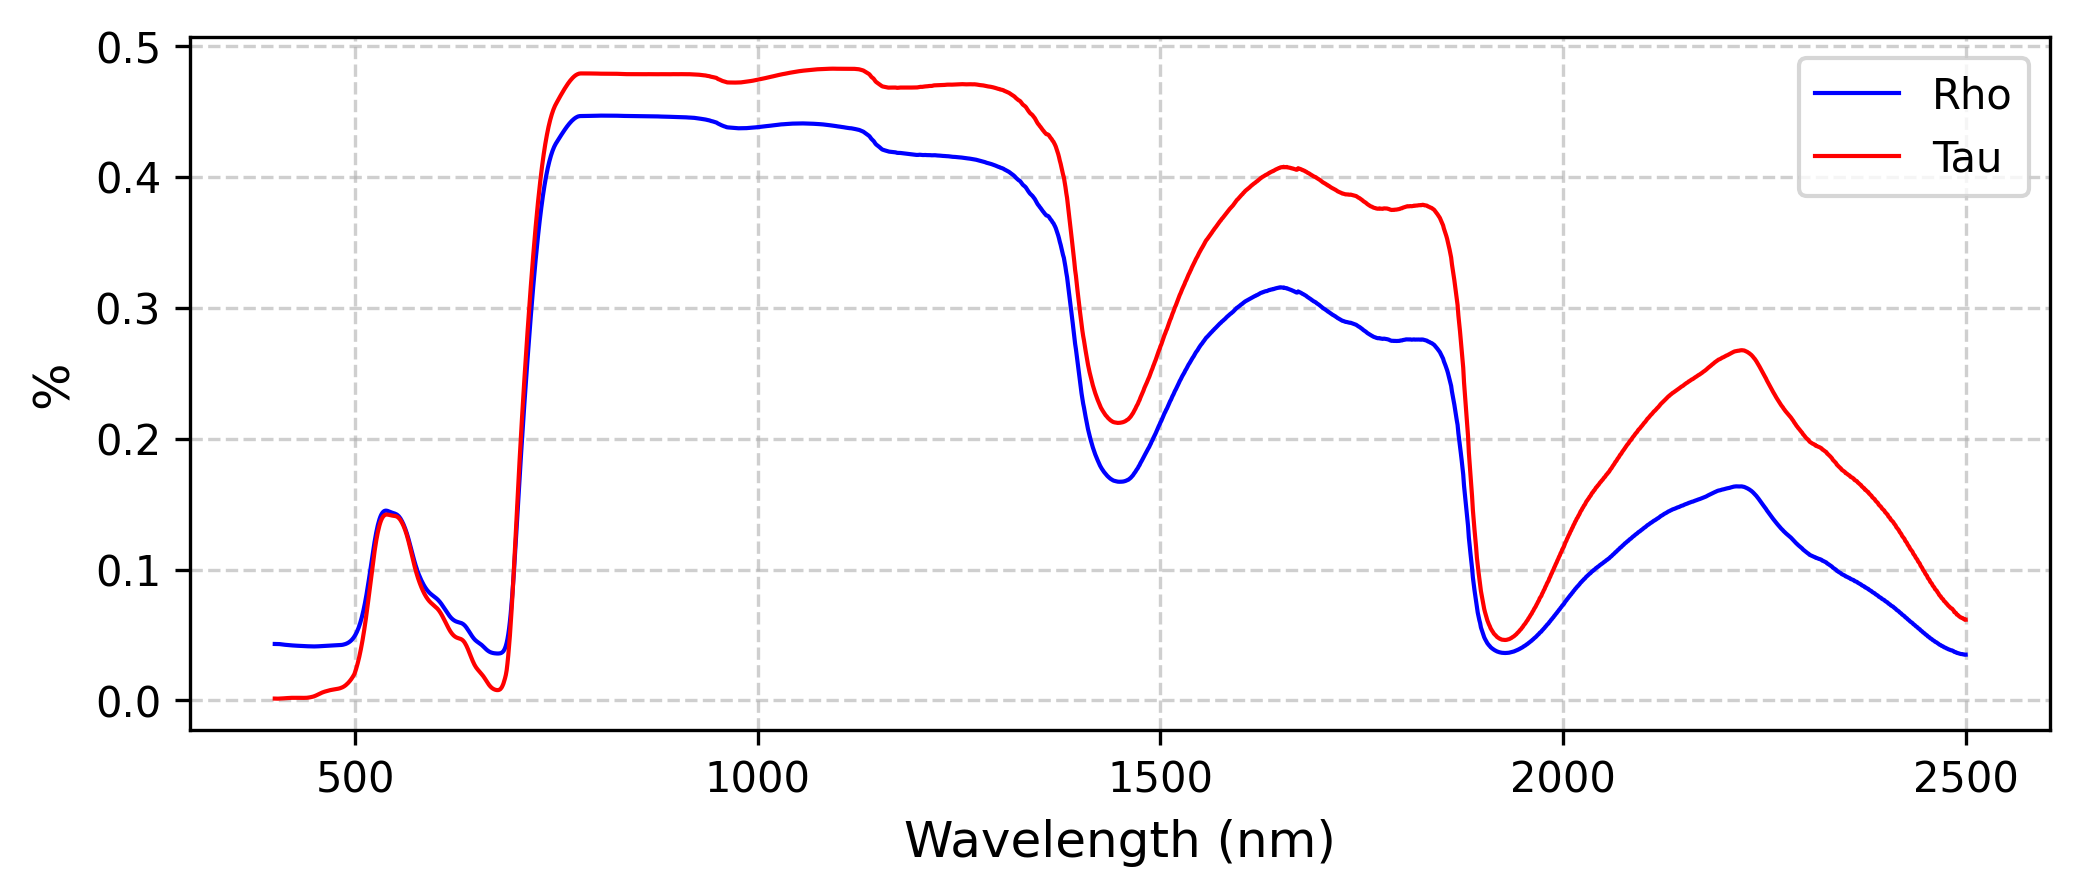

In [8]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt
# define the wavelength
wavelengths = np.arange(400, 2501)
# create the figure
plt.figure(figsize=(8, 3), dpi=300)
plt.plot(wavelengths, to_np(rho[0]), label='Rho', color='b', linewidth=1)
plt.plot(wavelengths, to_np(tau[0]), label='Tau', color='r', linewidth=1)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('%', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### PROSAIL-D: Canopy-Level Directional Reflectance

New we scale up from the leaf to the canopy level.

In [9]:
toc = prosail(traits,N,LIDFa,LIDFb,lai,q,tts,tto,psi,alpha,psoil,batch_size=1,prospect_type='prospect5d',lidtype=2)

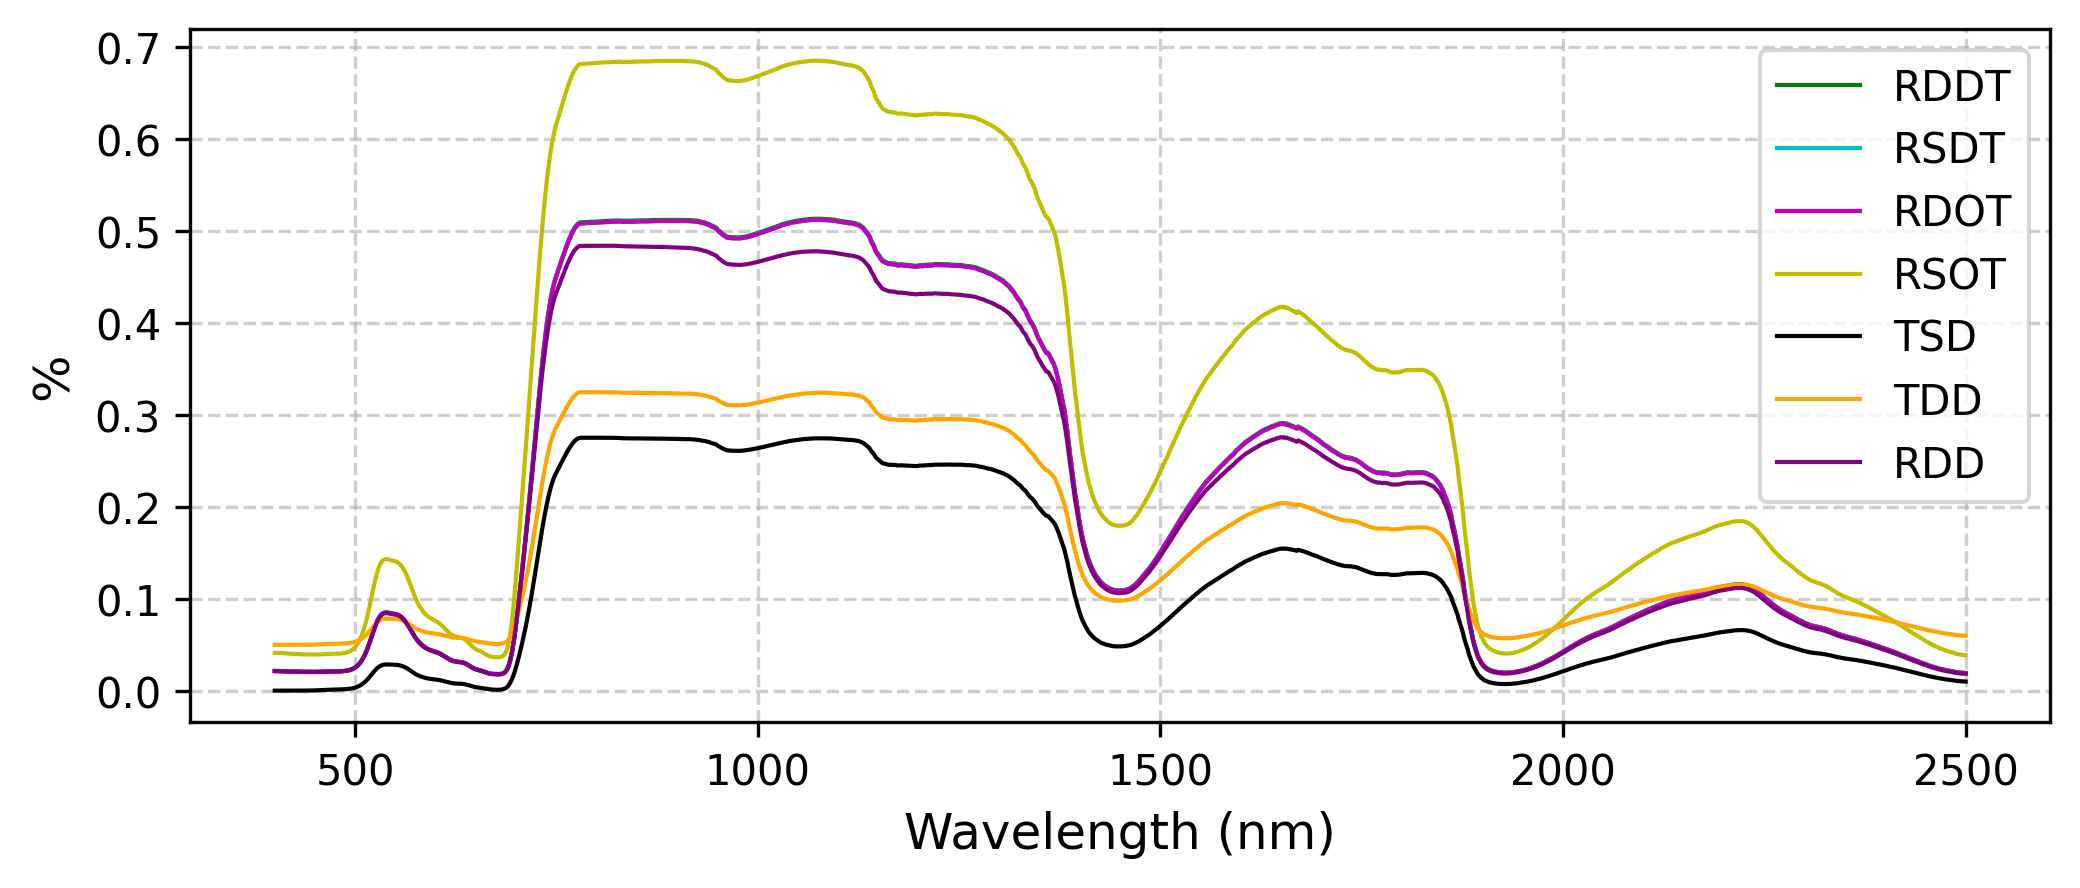

In [10]:
# @title
rddt, rsdt, rdot, rsot, tsd, tdd, rdd = toc
rddt, rsdt, rdot, rsot, tsd, tdd, rdd = rddt.t(), rsdt.t(), rdot.t(), rsot.t(), tsd.t(), tdd.t(), rdd.t()
# define the wavelength
wavelengths = np.arange(400, 2501)

# create the figure
plt.figure(figsize=(8, 3), dpi=300)
plt.plot(wavelengths, to_np(rddt[0]), label='RDDT', color='g', linewidth=1)
plt.plot(wavelengths, to_np(rsdt[0]), label='RSDT', color='c', linewidth=1)
plt.plot(wavelengths, to_np(rdot[0]), label='RDOT', color='m', linewidth=1)
plt.plot(wavelengths, to_np(rsot[0]), label='RSOT', color='y', linewidth=1)
plt.plot(wavelengths, to_np(tsd[0]), label='TSD', color='k', linewidth=1)
plt.plot(wavelengths, to_np(tdd[0]), label='TDD', color='orange', linewidth=1)
plt.plot(wavelengths, to_np(rdd[0]), label='RDD', color='purple', linewidth=1)

plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('%', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### SMAC: Generating Top-of-Atmosphere (TOA) Reflectance

Now we are ready for the next step: the atmosphere. WHich is to load the parameters for bands of different satellites.

TorchRTM includes SMAC implementations for all major satellite sensors.

In [11]:
from torchrtm.data.check_info_scrap import get_rs_info
names = get_rs_info()


Sentinel3B-OLCI.pkl
Sentinel3A-OLCI.pkl
TerraAqua-MODIS.pkl
Sentinel2B-MSI.pkl
Sentinel2A-MSI.pkl
LANDSAT4-TM.pkl
LANDSAT7-ETM.pkl
LANDSAT5-TM.pkl
LANDSAT8-OLI.pkl


Compute TOA (Top of Atmosphere) Reflectance for Each Sensor


In [12]:
from torchrtm.atmosphere.smac import smac
from torchrtm.data_loader import load_smac_sensor
toa_results = []

from torchrtm.atmosphere.smac import toc_to_toa


#for _ in [(names[0])]:
for _ in (names):

  coefs,sm_wl = load_smac_sensor(_.split('.')[0])
  Ta_s, Ta_o, T_g, ra_dd, ra_so, ta_ss, ta_sd, ta_oo, ta_do = smac(tts,tto,psi,coefs)
  # return to the R_TOA
  R_TOC, R_TOA = toc_to_toa(toc.permute(0, 2, 1).to(device), sm_wl-400, ta_ss, ta_sd, ta_oo, ta_do, ra_so, ra_dd, T_g, return_toc=True)
  toa_results.append([sm_wl,R_TOA])

Attempting to load sensor: Sentinel3B-OLCI
Attempting to load sensor: Sentinel3A-OLCI
Attempting to load sensor: TerraAqua-MODIS
Attempting to load sensor: Sentinel2B-MSI
Attempting to load sensor: Sentinel2A-MSI
Attempting to load sensor: LANDSAT4-TM
Attempting to load sensor: LANDSAT7-ETM
Attempting to load sensor: LANDSAT5-TM
Attempting to load sensor: LANDSAT8-OLI


Finally, we can visulaize the TOA reflectance based on all supported sensors in TorchRTM. This gives a multi-sensor view of TOA reflectance across MODIS, Landsat, Sentinel-2/3, and others...

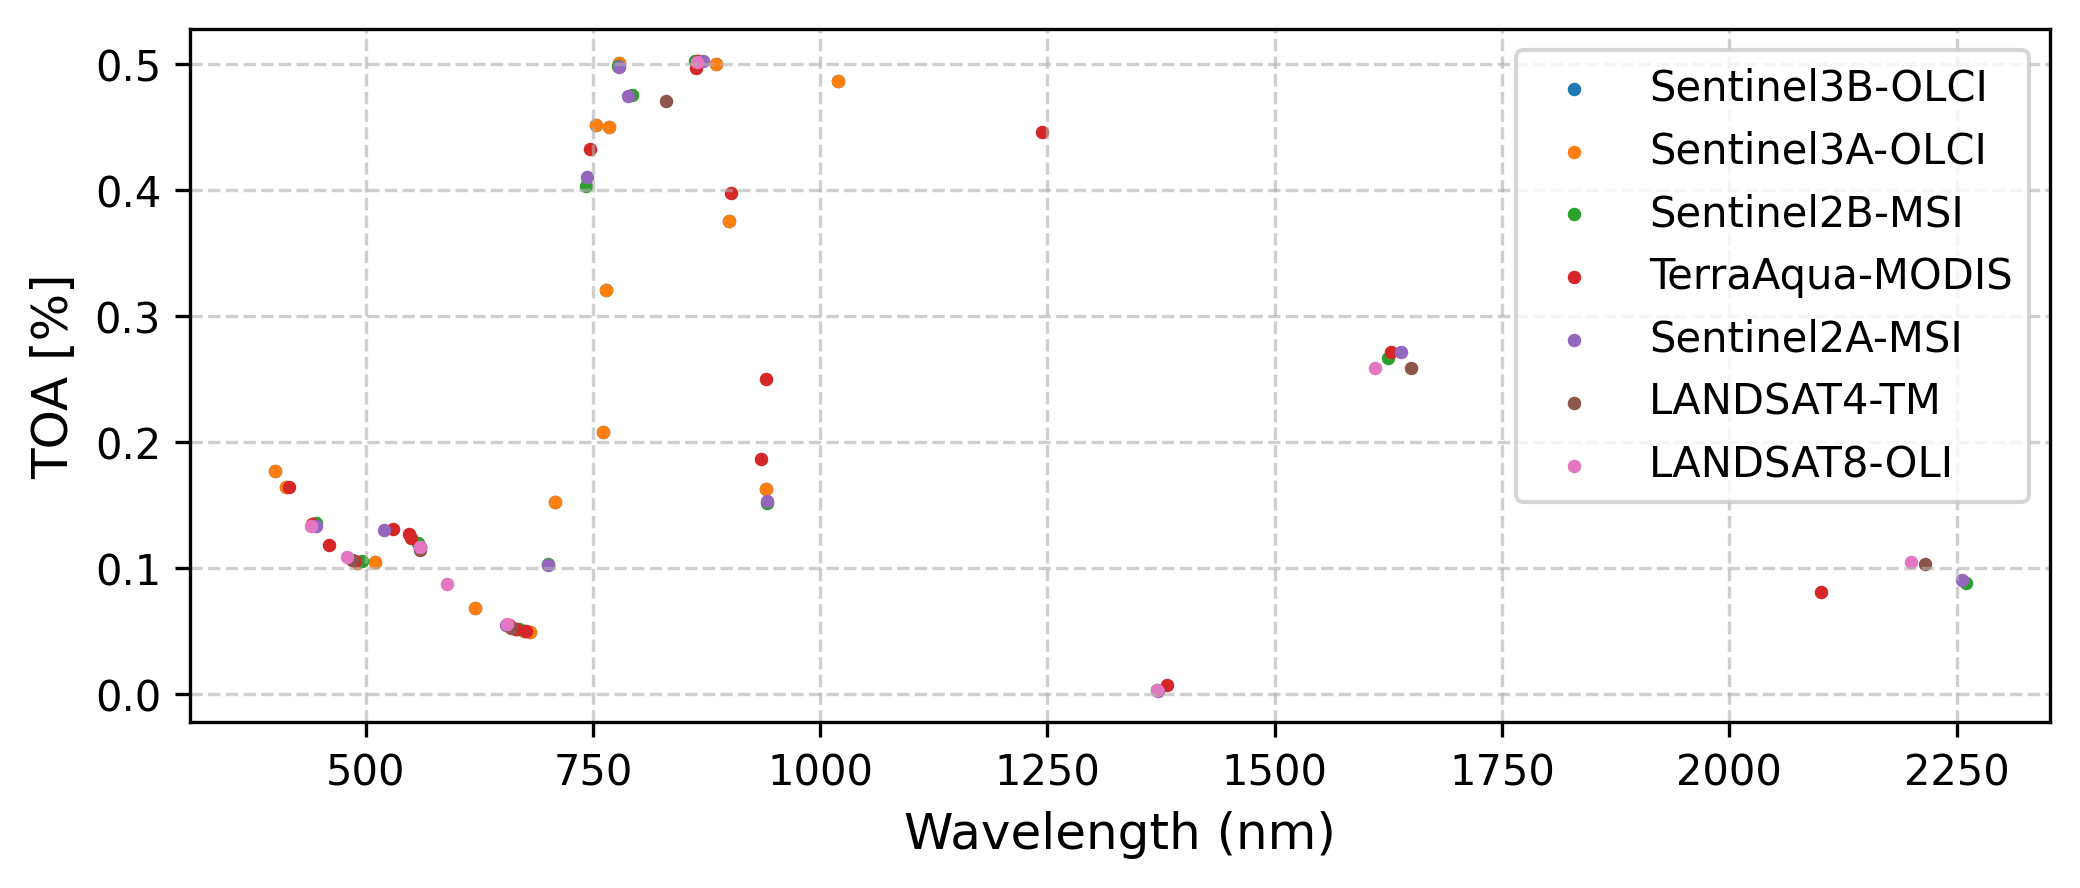

In [13]:
# @title
# Generate
sensor_list = names

plt.figure(figsize=(8, 3), dpi=300)
for _ in [0,1,3,2,4,5,8]:
  plt.scatter(toa_results[_][0], (toa_results[_][1][0].detach().cpu().numpy()), label=sensor_list[_].split('.')[0],s = 5)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('TOA [%]', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

#### Combine Leaf, Canopy, and Atmospheric Outputs

A final plot combines all predictions, and illustrates how spectral signals evolve from leaf → canopy → TOA.

This completes the forward-simulation pipeline.

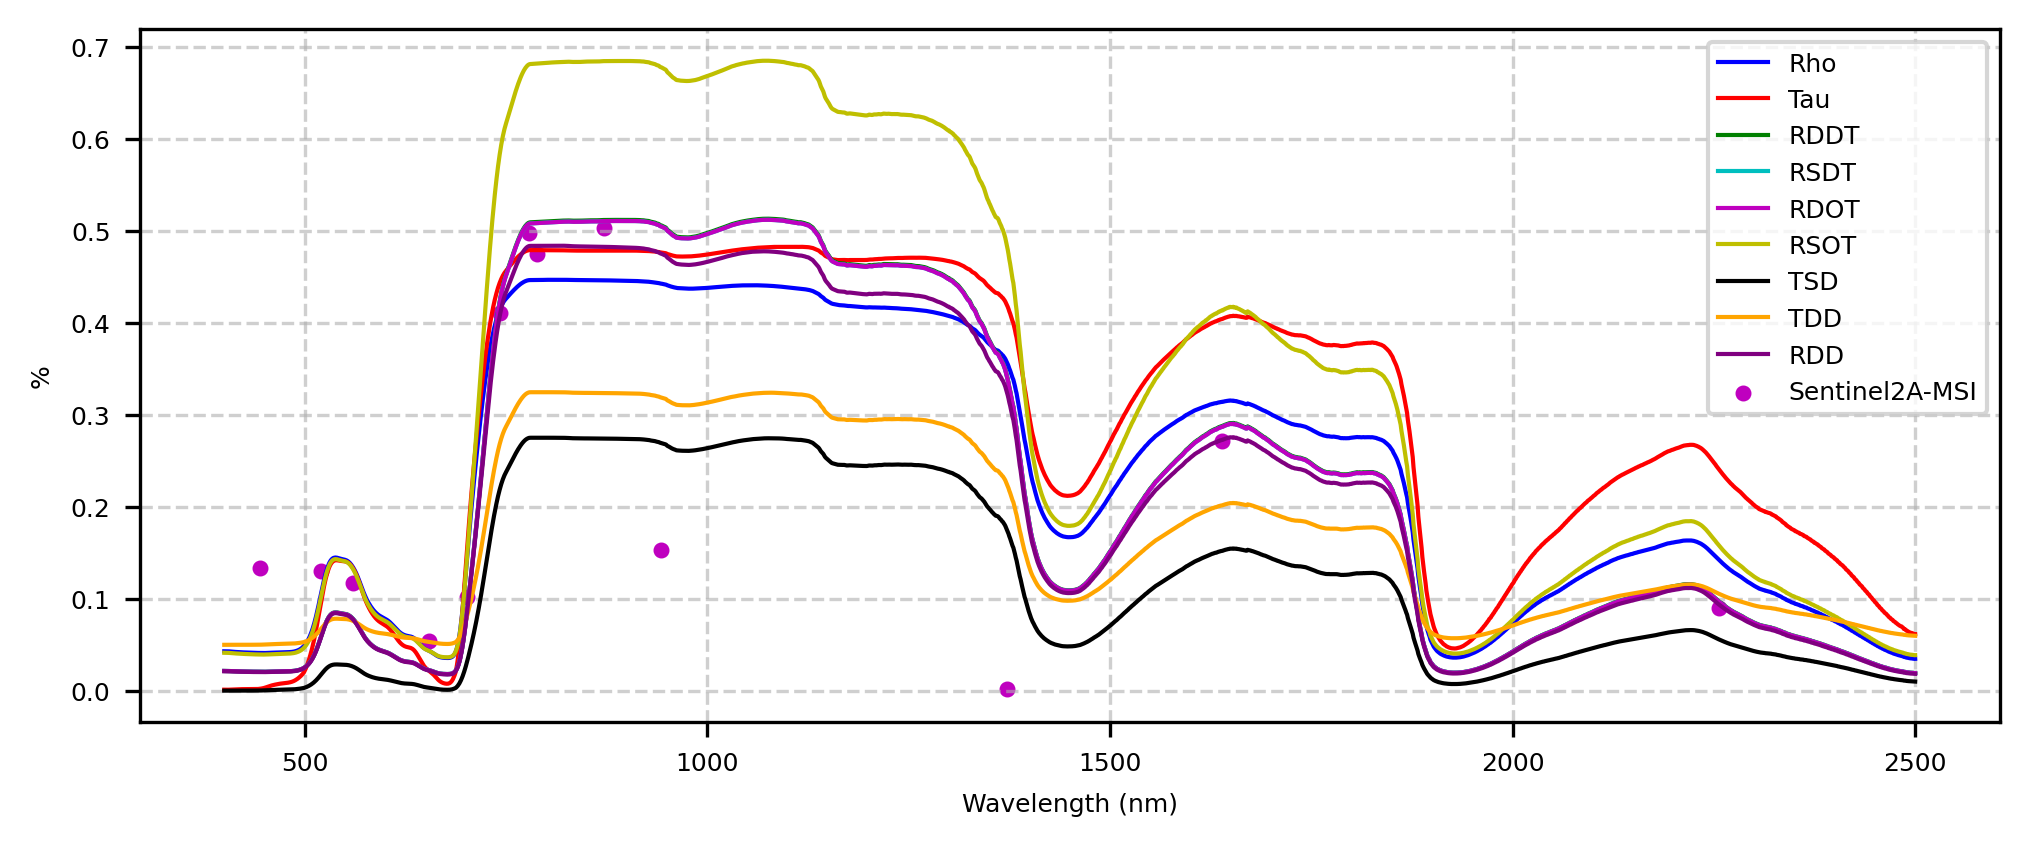

In [14]:
sensor_list = names

plt.figure(figsize=(8, 3), dpi=300)


wavelengths = np.arange(400, 2501)
# create the figure
plt.plot(wavelengths, to_np(rho[0]), label='Rho', color='b', linewidth=1)
plt.plot(wavelengths, to_np(tau[0]), label='Tau', color='r', linewidth=1)
plt.plot(wavelengths, to_np(rddt[0]), label='RDDT', color='g', linewidth=1)
plt.plot(wavelengths, to_np(rsdt[0]), label='RSDT', color='c', linewidth=1)
plt.plot(wavelengths, to_np(rdot[0]), label='RDOT', color='m', linewidth=1)
plt.plot(wavelengths, to_np(rsot[0]), label='RSOT', color='y', linewidth=1)
plt.plot(wavelengths, to_np(tsd[0]), label='TSD', color='k', linewidth=1)
plt.plot(wavelengths, to_np(tdd[0]), label='TDD', color='orange', linewidth=1)
plt.plot(wavelengths, to_np(rdd[0]), label='RDD', color='purple', linewidth=1)

plt.grid(True, linestyle='--', alpha=0.6)
for _ in [4]:
  plt.scatter(toa_results[_][0], (toa_results[_][1][0].detach().cpu().numpy()), color='m', label=sensor_list[_].split('.')[0],s = 8)

plt.tick_params(axis='both', labelsize=6)

plt.xlabel('Wavelength (nm)', fontsize=6)
plt.ylabel('%', fontsize=6)
plt.legend(fontsize=6)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

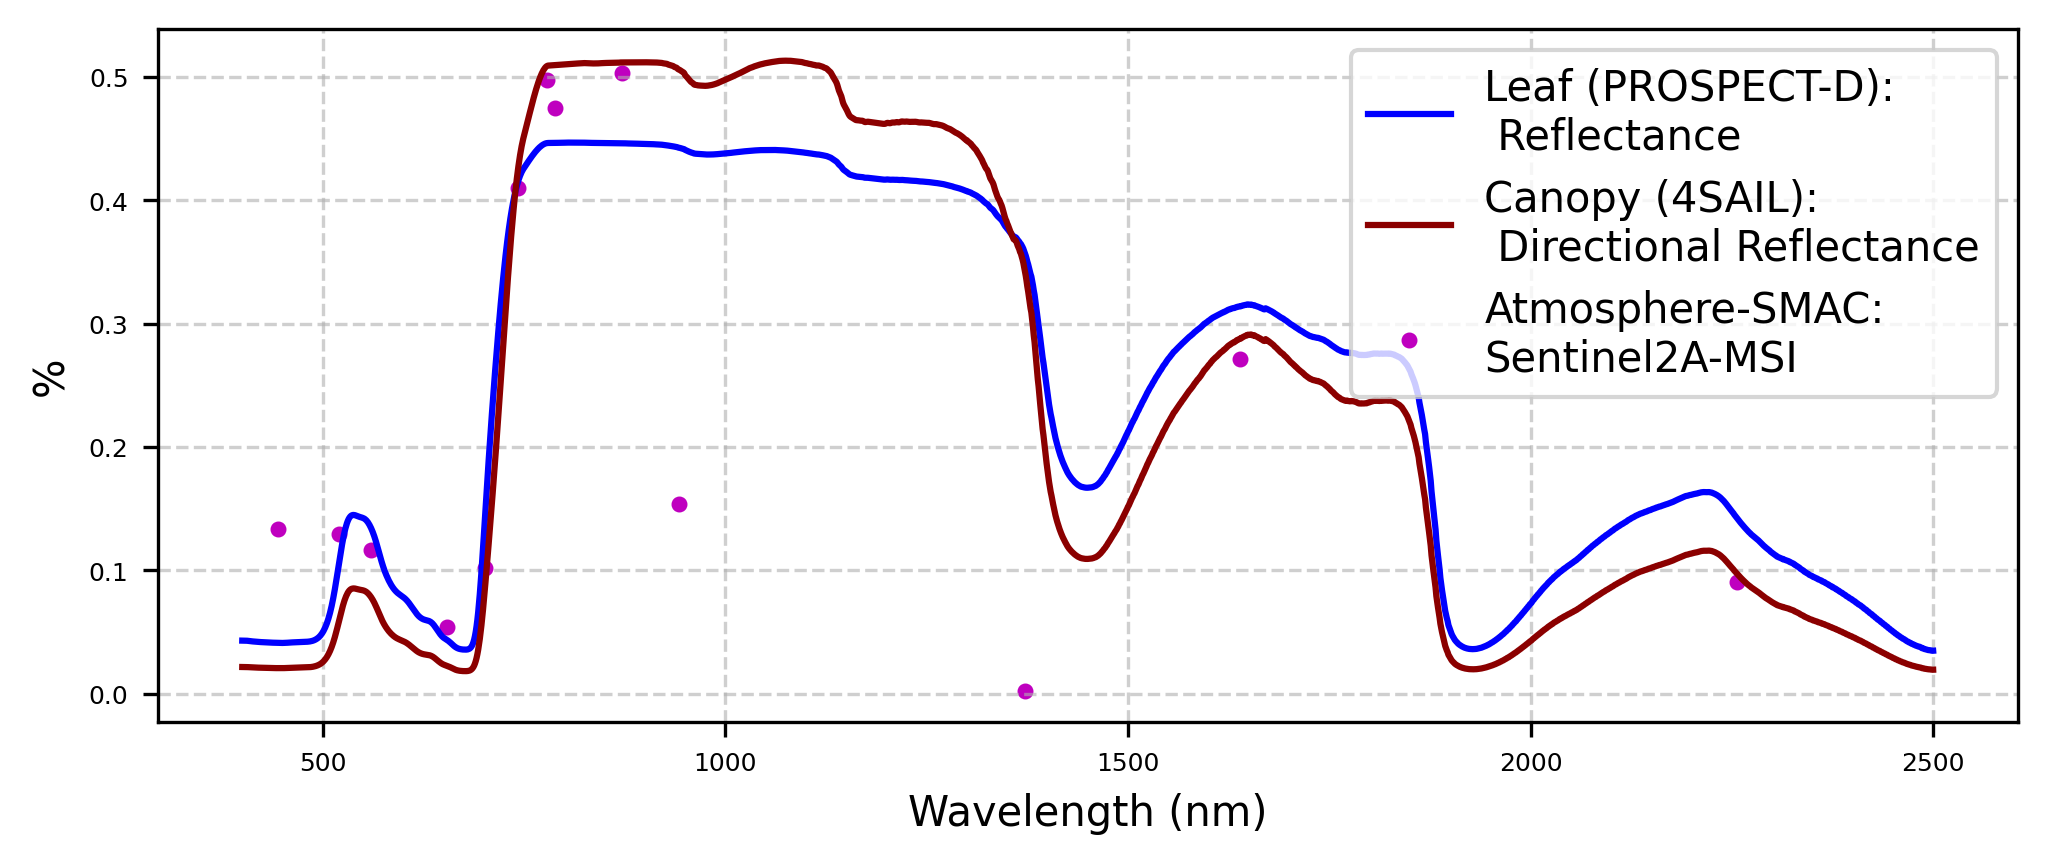

In [15]:
sensor_list = names

plt.figure(figsize=(8, 3), dpi=300)


wavelengths = np.arange(400, 2501)
# create the figure
plt.plot(wavelengths, to_np(rho[0]),
         label='Leaf (PROSPECT-D):\n Reflectance',
         color='b', linewidth=1.5)

plt.plot(wavelengths, to_np(rddt[0]),
         label='Canopy (4SAIL):\n Directional Reflectance',
         color='darkred', linewidth=1.5)

plt.grid(True, linestyle='--', alpha=0.6)
for _ in [4]:
  plt.scatter(toa_results[_][0], (toa_results[_][1][0].detach().cpu().numpy()), color='m', label='Atmosphere-SMAC:\n'+sensor_list[_].split('.')[0],s = 8)

plt.tick_params(axis='both', labelsize=6)

plt.xlabel('Wavelength (nm)', fontsize=10)
plt.ylabel('%', fontsize=10)
plt.legend(fontsize=10, loc='upper right')  # 右上角显示图例，字号10
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Inverse Mode: Estimating Leaf Traits From Reflectance Spectra

Forward simulations generate spectra from known biophysical parameters.
Inverse modelling does the opposite: it retrieves traits from measured reflectance. TorchRTM provides two complementary inversion methods:

1. A GPU-accelerated Look-Up Table (LUT)
2. A neural-network-based "Inverse-Net", designed for hybrid modelling and physics-informed learning

Both techniques are demonstrated using a real leaf-level dataset containing measured reflectance and laboratory-measured biochemical traits.


## Look-Up Table (LUT) Inversion

A LUT is the traditional workhorse of RTM inversion. It relies on simulating reflectance for many combinations of trait values and then selecting the parameter set whose simulated spectrum most closely matches the observed one.

### How the LUT works

1. Define parameter ranges (e.g., Cab, Car, Cw, Cm, leaf structure N).
2. Generate synthetic spectra for all parameter combinations using the forward model (e.g. PROSPECT-5B or PROSPECT-D).
3. Compare each observed spectrum with all simulated spectra using a cost function across wavelengths:
   $$
   \text{Cost} = \sum_{\lambda} \left| R_{\text{obs}}(\lambda) - R_{\text{sim}}(\lambda) \right|
   $$
4. Return the traits associated with the simulated spectrum that minimizes this cost.

### Some reasons on why LUT inversion is popular

* It's fast: no iterative optimisation is required.
* It's transparent: retrievals directly reflect similarity in spectral space.
* It's flexible: LUTs can be generated locally with user-defined parameter ranges.
* It's scalable in TorchRTM:  LUT generation and retrieval are done on the GPU, supporting dense, high-resolution tables.

We note that the LUTs in TorchRTM can serve both as a practical inversion tool but also as a baseline to compare against neural-network inversions.


##  PINNs: Neural-Network-Based Trait Retrieval

The Inverse-Net function in torch provides a modern alternative to LUTs. It learns a mapping from reflectance spectra to leaf traits and is suitable for:

* supervised inversion using measured datasets,
* large-scale applications requiring fast inference,
* integration into hybrid deep-learning architectures,
* embedding inside physics-informed neural networks (PINNs),
* autoencoder-style frameworks where an RTM acts as the decoder.

Unlike LUTs—whose accuracy is bounded by grid resolution. Inverse-Net models can generalise smoothly across parameter space and support end-to-end optimisation with differentiable RTM components.


##  Dataset for Demonstration

To illustrate both inversion methods, we use a publicly available leaf-reflectance dataset containing:

* hyperspectral reflectance at the leaf level,
* measured values of chlorophyll, carotenoids, water content, dry-matter content, and anthocyanins.

Spectral variables are separated from trait variables, and units are converted to those required by radiative-transfer models (for example, converting water content from mg/cm² to g/cm² and converting SLA to dry-matter content).

This dataset provides a realistic inversion scenario and allows direct comparison between LUT-based retrieval and neural-network predictions.

## What Comes Next in the Tutorial

The following notebook sections will walk through:

### A. LUT construction and inversion

* constructing a user-defined LUT using PROSPECT-D,
* retrieving traits using TorchRTM’s fast GPU lookup engine,
* evaluating retrieval accuracy using regression diagnostics.

Then we tackle the more complex PINN part.

### B. Hybrid and physics-informed inversion

* embedding Inverse-Net within an autoencoder,
* using PROSPECT-D or PROSAIL as a differentiable decoder,
* enforcing physical consistency during training.


In [8]:
from torchrtm.utils.torch_utils import load_prosail_params
from torchrtm.leaf.prospect import prospect5b,prospectd
from torchrtm.utils.torchlut import Torchlut
from torchrtm.retrival.fastLUT import Torchlut_pred


In [9]:
import pandas as pd

# 1. Load dataset directly from the online ECOSIS repository
url = "http://data.ecosis.org/dataset/3cf6b27e-d80e-4bc7-b214-c95506e46daa/resource/1827b371-b161-4f60-955f-59df7e18df8c/download/leaf_kit_plant_functional_gradient.csv"
case_data = pd.read_csv(url, encoding='latin')

# 2. Clean the dataset: drop the first row and reset the index
case_data = case_data.iloc[1:].reset_index(drop=True)

# 3. Separate spectral data (reflectance) from trait data
ifgg_spectra = case_data.iloc[:, 13:].astype(float)

# 4. Extract relevant leaf functional traits
ifgg_traits = pd.DataFrame({
    "Cab": case_data["Chlorophyll content (µg/cm²)"],
    "Car": case_data["Carotenoid content (µg/cm²)"],
    "Cw": case_data["LWC (mg/cm²)"],          # leaf water content
    "Cm": case_data["SLA (g/cm²)"],           # specific leaf area
    "Anth": case_data["Anthocyanin content (µg/cm²)"]
}).astype(float)

# 5. Unit conversions
# Convert Cw from mg/cm² to g/cm²
ifgg_traits["Cw"] = ifgg_traits["Cw"] / 1000
# Convert SLA (cm²/g) to dry matter content (g/cm²)
ifgg_traits["Cm"] = 1 / ifgg_traits["Cm"]

# 6. Display dataset dimensions and a sample of the trait data
print(ifgg_spectra.shape, ifgg_traits.shape)
ifgg_traits.head()


(739, 2101) (739, 5)


,Cab,Car,Cw,Cm,Anth
0,26.534559,7.491958,0.022186,0.009376,0.996766
1,24.610562,7.527212,0.012693,0.003409,1.217297
2,29.192563,8.546976,0.015226,0.004540,1.142859
3,69.231225,11.548418,0.021393,0.007293,2.262477
4,39.882560,9.080115,0.013684,0.004212,1.733784


Here, we demonstrate that how to change the range of input parameters for RTMs.

In [10]:

new_range = load_prosail_params()
new_range

,para,min,max
0,lai,1.000000,15.000
1,LIDFa,-1.000000,1.000
2,LIDFb,-1.000000,1.000
3,hspot (q also),0.000001,1.000
4,tts,0.000000,90.000
5,tto,0.000000,90.000
6,psi,0.000000,180.000
7,psoil,0.000000,1.000
8,N,1.000000,5.000
9,Cab,10.000000,200.000


In [11]:
new_range.iloc[10,2] = 20
new_range.iloc[14,2] = 5

We first use simulated spectra based on random traits as a test set.
The LUT can be created with a single line of code. The key parameters are table size, the number of candidate sets, and Gaussian noise standard deviation:


In [12]:
"""
torchrtm.utils.torch_utils
--------------------------

General-purpose torch utilities.
"""

import torch
import numpy as np
from scipy.stats import qmc
from tqdm import tqdm
#from torchrtm.models import prosail
from torchrtm.utils import normalize_parameters
from torchrtm.leaf.prospect import prospect5b, prospectd, prospectpro


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def Torchlut(model = 'prospect5b', table_size=500000, std=0, batch=10000, wavelength=None,sensor_name = 'LANDSAT4-TM',sail_prospect = 'prospectd',use_atom = False,para_addr=None):
    # Initialize Latin Hypercube Sampler

    batch = min(table_size,batch)
    import math
    d = 18

    #from torchrtm.atmosphere.smac import toc_to_toa


    if use_atom == True:
        param_type = 'atom'
        from torchrtm.models import prosail
        simulator = prosail
        from torchrtm.atmosphere.smac import smac
        from torchrtm.data_loader import load_smac_sensor
        from torchrtm.atmosphere.smac import toc_to_toa

    else:
        if model == 'prosail':
            from torchrtm.models import prosail
            simulator = prosail
        elif model == 'prospect5b':
            simulator = prospect5b
        elif model == 'prospectd':
            simulator = prospectd
        elif model == 'prospectpro':
            simulator = prospectpro
        param_type= simulator.__name__
    print(param_type)
    sampler = qmc.LatinHypercube(d=d)
    samples = sampler.random(n=table_size)
    ref_list = []
    para_list = []
    # Determine the total number of iterations
    num_iterations = max(1, math.ceil(table_size / batch))
    # Loop to process samples in batches with a progress bar
    print_flag = True
    for ii_index in tqdm(range(num_iterations), desc="Processing Batches"):
        test_num = batch
        # Generate a subset of samples and convert to PyTorch tensor
        many_paras = torch.tensor(samples[batch * ii_index:batch * (ii_index + 1), :]).to(torch.float32).to(device)
        #print(many_paras[0])
        # Example normalization function placeholder; replace with actual normalization if needed
        many_paras[:,:17] = normalize_parameters(many_paras[:,:17],param_type='prosail', fitting=False,para_addr=para_addr)
        #print(many_paras[0])

        #real_paras = normlization_torch(many_paras, param_type=param_type, fitting=False)
        # Pass through prospect5b model
        if param_type in ['prospectd', 'prospect5b','prospectpro']:
            # For PROSPECT models: typically (leaf_params, LAI) or similar structure
            if param_type == 'prospectd':
                spec_data = simulator(many_paras[:, 9:15], many_paras[:, 8])[0]
                para_list.append(many_paras[:,8:15].cpu().numpy())

            elif param_type == 'prospect5b':
                spec_data = simulator(many_paras[:, 9:14], many_paras[:, 8][0])
                para_list.append(many_paras[:,8:14].cpu().numpy())
            elif param_type == 'prospectpro':
                spec_data = simulator(many_paras[:, [9,10,11,12,14,15,16]], many_paras[:, 8])[0]
                para_list.append(many_paras[:,8:17].cpu().numpy())
        else:
            if param_type == 'atom':
                  many_paras[:,-3:] = normalize_parameters(many_paras[:,-3:],param_type=param_type, fitting=False,para_addr=para_addr)

            lai = many_paras[:,0]
            LIDFa = many_paras[:,1]
            LIDFb = many_paras[:,2]
            q = many_paras[:,3]
            tts = many_paras[:,4]
            tto = many_paras[:,5]
            psi = many_paras[:,6]
            psoil = many_paras[:,7]
            N = many_paras[:,8]
            Cab = many_paras[:,9]
            Car = many_paras[:,10]
            Cbrown = many_paras[:,11]
            Cw = many_paras[:,12]
            Cm = many_paras[:,13]
            Canth = many_paras[:,14]
            prot = many_paras[:,15]
            Cbc = many_paras[:,16]



            alpha = torch.tensor(40).to(device).expand([test_num])
            tran_alpha = alpha.clone()
            if sail_prospect == 'prospectd':
                traits = torch.stack([Cab,Car,Cbrown,Cw,Cm,Canth],dim = 1)
                spec_data = simulator(traits,N,LIDFa,LIDFb,lai,q,tts,tto,psi,tran_alpha,psoil,batch_size=1,prospect_type='prospect5d',lidtype=2)
            elif sail_prospect == 'prospect5':
                traits = torch.stack([Cab,Car,Cbrown,Cw,Cm],dim = 1)
                spec_data = simulator(traits,N,LIDFa,LIDFb,lai,q,tts,tto,psi,tran_alpha,psoil,batch_size=1,prospect_type='prospect5b',lidtype=2)
            elif sail_prospect == 'prospectpro':
                traits = torch.stack([Cab,Car,Cbrown,Cw,Canth,prot,Cbc],dim = 1)
                spec_data = simulator(traits,N,LIDFa,LIDFb,lai,q,tts,tto,psi,tran_alpha,psoil,batch_size=1,prospect_type='prospectpro',lidtype=2)
            if param_type == 'atom':
                aot550 = many_paras[:,-3]
                uo3 = many_paras[:,-2]
                uh2o = many_paras[:,-1]
                coefs,sm_wl = load_smac_sensor(sensor_name.split('.')[0])
                Ta_s, Ta_o, T_g, ra_dd, ra_so, ta_ss, ta_sd, ta_oo, ta_do = smac(tts,tto,psi,coefs)
                # return to the R_TOA
                #sm_wl = np.arange(400,2501)
                #print(spec_data.permute(0, 2, 1).shape,ta_ss.shape, ta_sd.shape, ta_oo.shape, ta_do.shape) for debug
                R_TOC, R_TOA = toc_to_toa(spec_data.permute(0, 2, 1).to(device), sm_wl-400, ta_ss, ta_sd, ta_oo, ta_do, ra_so, ra_dd, T_g, return_toc=True)
                if print_flag:
                    print('now is using selected wavelength:')
                    print(sm_wl)
                    print_flag = False
                spec_data = (R_TOA)
                para_list.append(many_paras.cpu().numpy())

            if param_type=='prosail':

                tts_rad = torch.deg2rad(tts)

                sin_90tts = torch.sin(math.pi / 2 - tts_rad)

                skyl = 0.847 - 1.61 * sin_90tts + 1.04 * sin_90tts ** 2
                PARdiro = (1.0 - skyl)
                PARdifo = skyl

                #print(sin_90tts, skyl, PARdiro, PARdifo) for debug

                sin_90tts = torch.sin(math.pi / 2 - tts)

                skyl = 0.847 - 1.61 * sin_90tts + 1.04 * sin_90tts ** 2
                PARdiro = (1.0 - skyl)#.unsqueeze(1)
                PARdifo = skyl#.unsqueeze(1)
                resv = (spec_data[2].to(device) * PARdifo + spec_data[3].to(device) * PARdiro) / (PARdiro + PARdifo)
                spec_data = resv.T
                para_list.append(many_paras[:,:15].cpu().numpy())
        ref_list.append(spec_data.cpu().numpy())

    # Combine lists into arrays
    para_list = np.vstack(para_list)
    ref_list = np.vstack(ref_list)

    if std != 0:
        noise = np.random.normal(loc=0.0, scale=std, size=ref_list.shape)
        ref_list += noise

    if wavelength is not None and len(wavelength) > 0:
      return ref_list[:,wavelength-400], para_list#[:,wavelength-400]
    else:
      return ref_list, para_list

In [13]:


simulated_spectra, initial_traits = Torchlut ('prospectd', table_size = 500000, std = 0,para_addr=new_range)
#validate_spectra, validate_traits = Torchlut (prospectd,table_size = 1000, std = 0,para_addr=new_range)


prospectd


Processing Batches: 100%|██████████| 50/50 [00:20<00:00,  2.42it/s]


Next, we use the validation spectra as a query and set the number of candidates to retrieve predictions from the test set (see the result in Figure 2A):

In [14]:
simulated_spectra = to_cuda(simulated_spectra)#.cpu()
initial_traits = to_cuda(initial_traits)#.cpu()
validate_spectra = to_cuda(ifgg_spectra.values)#.cpu()



In [23]:
k=5
_ = 9 # set up the distance_order
lut_pred = Torchlut_pred(xb = simulated_spectra, xq=validate_spectra, k=k,y=initial_traits,distance_order=_)

Processing query blocks: 100%|██████████| 4/4 [00:27<00:00,  6.85s/it]


In [15]:

lut_pred = (lut_pred)

lut_pred_np = lut_pred.detach().cpu().numpy()
lut_pred_np = lut_pred_np[:,[1,2,4,5,6]]

NameError: name 'lut_pred' is not defined

In [ ]:
case_traits_list = ["Cab (μg/cm²)", "Car (μg/cm²)", "Cw (g/cm²)", "Cm (g/cm²)", "Anth (μg/cm²)"]


### Prediction results

In [ ]:
plot_regressions(ifgg_traits.values,lut_pred_np,case_traits_list)

## Optional Blocks: Selecting the Distance Order for LUT Inversion

In LUT-based inversion, the choice of distance metric used to compare observed and simulated spectra can strongly influence retrieval accuracy. TorchRTM allows users to adjust this behaviour through the parameter distance_order, which generalises the spectral distance function using different norms.

The distance order determines how differences across wavelengths are aggregated:

- Lower orders (e.g., 1 or 2) emphasise broad, overall similarity between spectra.

- Higher orders (e.g., 6–9) place more weight on large deviations at specific wavelengths.

This can be useful when certain spectral regions are particularly informative for the traits of interest or when the noise characteristics of the instrument vary across wavelengths.

In this optional block, we illustrate how to systematically evaluate different values of distance_order using a real dataset. By varying the order from 2 to 9, we assess how sensitive the LUT inversion is to the choice of spectral distance metric. For each value, a fixed number of nearest neighbours is retrieved from the LUT and used to estimate traits, and the predictions are evaluated using standard diagnostics such as RMSE, R², and regression slope.

The procedure is included as it allows users to identify the distance metric that yields the most accurate trait retrieval for their specific dataset. The LUT engine can be tuned to accommodate different spectral noise profiles, measurement conditions, or retrieval objectives.

The resulting error metrics across distance orders provide a practical guide for selecting an appropriate distance function when working with new or heterogeneous datasets.

In [ ]:
results = []
for i in range(2,10):
  k=5
  pred = Torchlut_pred(xb = simulated_spectra, xq=validate_spectra, k=k,y=initial_traits,distance_order=i)
  pred_np = pred.detach().cpu().numpy()
  pred_np = pred_np[:,[1,2,4,5,6]]
  result_sub = plot_regressions(ifgg_traits.values,pred_np,ifgg_traits.columns)
  results.append([*result_sub.RMSE.values])

In [ ]:
results = np.array(results, dtype=float)
results = pd.DataFrame(results)
results.columns = result_sub.Feature
results.index = np.arange(2,10)
results

# Inverse-Net: Integrating Radiative Transfer Models Into Deep Learning

This section demonstrates how radiative transfer models can be embedded directly within a deep learning framework. The objective is to create an encoder:decoder architecture in which:

* the encoder is a neural network that predicts leaf traits from spectra, and
* the decoder is the physical RTM (PROSPECT-D), which reconstructs spectra from those traits.

This structure mirrors a classical autoencoder, but with a physics-based decoder, ensuring that the learned trait estimates remain physically meaningful and consistent with radiative-transfer principles (see Sun et al 2025 RSE, and maintext). Because both components operate within PyTorch, the entire system is fully differentiable and can be trained end-to-end using standard deep-learning optimisation tools.

##  Encoder: Neural Network for Trait Estimation

The encoder is a multi-layer neural network constructed using TorchRTM's built-in `Inverse_Net` module. It maps high-dimensional spectral input (~2100 wavelengths) to a small set of RTM parameters. By specifying the number of neurons in each layer, users can easily define architectures ranging from lightweight networks for real-time inversion to deeper models for complex retrieval tasks (i.e. hyperparameter optimization is still needed).

The encoder outputs trait estimates in a normalised domain. These estimates are then passed into the decoder to reconstruct spectra, enabling joint optimisation of trait accuracy and spectral fidelity.


## Decoder: PROSPECT-D as a Differentiable Physical Model

The decoder in our example uses the PROSPECT-D model as implemented in TorchRTM. It converts predicted trait values into simulated leaf reflectance. Because the decoder is expressed as a PyTorch module, gradients propagate through every RTM operation, linking errors in reconstructed spectra back to errors in trait predictions. This integration turns the entire inversion process into a hybrid PINN pipeline.

Normalisation is applied to the predicted parameters before they enter the decoder, ensuring that the traits remain within physically valid bounds and consistent units.




### Setting up the encoder and decoder
Setting up the encoder has been made very easy in TorchRTM, just specify the encoder size.

In [5]:
# Define network architecture and move to device
layer_sizes = [2101, 444, 7]  # Input: spectral bands; Output: 7 RTM parameters
encoder = Inverse_Net(layer_sizes, use_attention=False, dropout_rate=0).to(device)  # Trait estimation network

Next, we set up the decoder,  The decoder is based on PROSPECT5D and is implemented as a PyTorch class.:

In [6]:
from torchrtm.leaf.prospect import  prospectd
import torch.nn as nn

class ProspectDecoder(nn.Module):
    def __init__(self):
        super(ProspectDecoder, self).__init__()
    def forward(self, many_paras):
        real_paras = normalize_parameters(many_paras,fitting = False,param_type='prospectd',use_torch = True,para_addr= new_range) #normlization_torch(many_paras, fitting=False)  # Normalize the input parameters
        refs = prospectd(real_paras[:, 1:], real_paras[:, 0])    # Apply the prospect5 model
        return refs[0][:, :]  # Return the processed output excluding the last 50 elements
decoder = ProspectDecoder().to(device)  # Initialize the decoder and move it to the device


## Dataset Preparation and Batching

The measured reflectance spectra and corresponding biochemical traits are organised into training and validation subsets. As is typical in ML, PyTorch DataLoaders feed data to the model in mini-batches, enabling efficient GPU utilisation and reproducible training dynamics. The data are split into equal training and validation sets to allow separate monitoring of reconstruction accuracy and trait-prediction accuracy.


In [16]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
from torchrtm.retrival.fastNN import Inverse_Net

# X = spectra y =traits
X = torch.tensor(ifgg_spectra.values, dtype=torch.float32)
y = torch.tensor(ifgg_traits.values, dtype=torch.float32)

# 8:2 拆分
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=42)

# 构建 DataLoader
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)


## Example of a training strategy

Training optimises both the encoder and the decoder jointly. The loss function combines three components:

1. Spectral reconstruction loss:    Quantifies how well the decoder rebuilds the input spectrum. Lower reconstruction error here indicates that the predicted traits generate physically plausible spectra.

2. Trait estimation loss: Measures the difference between predicted and reference trait values. This is like a prior in Bayesian analyses. The term ensures that trait retrieval is accurate, not only spectrally consistent.

3. Validation reconstruction loss: Typical autoencoder loss, which acts as a regularisation mechanism to prevent overfitting and stabilise learning.

These components are combined with appropriate weighting. The optimiser updates only the encoder's parameters, while the decoder remains a fixed physical model.

Training iterates through mini-batches, dynamically reconstructing spectra, computing losses, and updating parameters. Throughout training, validation losses are monitored to assess generalisation.

In [17]:


# Define loss function and optimizer
optimizer = torch.optim.AdamW(encoder.parameters(), lr=1e-3)
num_epochs = 600

# ---- Custom MSE that ignores NaN values (for incomplete observations) ----
def nan_mse_loss(pred, target):
    mask = ~torch.isnan(target)
    return torch.mean((pred[mask] - target[mask]) ** 2)

criterion = nan_mse_loss

# Create validation iterator
val_iter = iter(val_loader)

# Record all losses per epoch: [train_total, loss_recon, loss_trait, loss_val_recon, loss_val_trait]
loss_recording = []

for epoch in range(num_epochs):
    encoder.train()
    running_loss = 0.0
    total_recon_loss = 0.0
    total_trait_loss = 0.0
    total_val_recon_loss = 0.0

    # ---- TRAINING PHASE ----
    for batch_spectra, batch_traits in train_loader:
        batch_spectra = batch_spectra.to(device)
        batch_traits = batch_traits.to(device)

        # 1) Forward pass through encoder (spectra → traits)
        pred_traits = torch.sigmoid(encoder(batch_spectra))

        # 2) Decode traits back into spectra using the RTM (decoder)
        recon_spectra = decoder(pred_traits)

        # --- Compute sub-losses ---
        # a) Spectral reconstruction loss:
        #quantifies the discrepancy between reconstructed and training spectra.

        loss_recon = criterion(recon_spectra, batch_spectra)

        # b) Trait estimation loss: error between predicted and reference traits
        loss_trait = criterion(
            normalize_parameters(pred_traits, fitting=False, param_type='prospectd', use_torch=True)[:, [1, 2, 4, 5, 6]],
            batch_traits
        )

        # c) Spectral reconstruction loss:
        #quantifies the discrepancy between reconstructed and spectra in validation set

        val_spectra, _ = next(val_iter, (None, None))
        if val_spectra is None:  # Reset iterator if exhausted
            val_iter = iter(val_loader)
            val_spectra, _ = next(val_iter)
        val_spectra = val_spectra.to(device)
        pred_val = torch.sigmoid(encoder(val_spectra))
        recon_val = decoder(pred_val)
        loss_recon_val = criterion(recon_val, val_spectra)

        # --- Combine losses ---
        # Weighted combination of losses:
        #   reconstruction (main objective)
        # + trait loss (scaled by 0.1)
        # + validation reconstruction (regularization)
        loss = loss_recon + loss_trait / 10 + loss_recon_val

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total_recon_loss += loss_recon.item()
        total_trait_loss += loss_trait.item()
        total_val_recon_loss += loss_recon_val.item()

    # ---- VALIDATION PHASE ----
    encoder.eval()
    with torch.no_grad():
        val_recon_loss = 0.0
        val_trait_loss = 0.0
        for val_spectra, val_traits in val_loader:
            val_spectra = val_spectra.to(device)
            val_traits = val_traits.to(device)

            pred_val_traits = torch.sigmoid(encoder(val_spectra))
            recon_val_spectra = decoder(pred_val_traits)

            # a) Spectral reconstruction on validation set
            val_recon_loss += criterion(recon_val_spectra, val_spectra).item()

            # b) Trait prediction accuracy on validation set
            val_trait_loss += criterion(
                normalize_parameters(pred_val_traits, fitting=False, param_type='prospectd', use_torch=True)[:, [1, 2, 4, 5, 6]].cpu(),
                val_traits.cpu()
            )

    # ---- Epoch summary ----
    print(f"Epoch {epoch+1:02d} | "
          f"Train Total: {running_loss/len(train_loader):.6f} | "
          f"Recon: {total_recon_loss/len(train_loader):.6f} | "
          f"Trait: {total_trait_loss/len(train_loader):.6f} | "
          f"Val Recon: {val_recon_loss/len(val_loader):.6f} | "
          f"Val Trait: {val_trait_loss/len(val_loader):.6f}")

    # Record all losses
    loss_recording.append([
        running_loss / len(train_loader),
        total_recon_loss / len(train_loader),
        total_trait_loss / len(train_loader),
        val_recon_loss / len(val_loader),
        val_trait_loss / len(val_loader)
    ])


Epoch 01 | Train Total: 39.430493 | Recon: 0.004552 | Trait: 394.211418 | Val Recon: 0.004356 | Val Trait: 128.941971
Epoch 02 | Train Total: 13.815854 | Recon: 0.003710 | Trait: 138.085561 | Val Recon: 0.003101 | Val Trait: 140.228073
Epoch 03 | Train Total: 14.366815 | Recon: 0.003530 | Trait: 143.599968 | Val Recon: 0.003004 | Val Trait: 139.382370
Epoch 04 | Train Total: 13.691482 | Recon: 0.003135 | Trait: 136.853605 | Val Recon: 0.002556 | Val Trait: 123.995239
Epoch 05 | Train Total: 9.612868 | Recon: 0.002689 | Trait: 96.076302 | Val Recon: 0.002432 | Val Trait: 46.864475
Epoch 06 | Train Total: 5.490351 | Recon: 0.002628 | Trait: 54.851767 | Val Recon: 0.002352 | Val Trait: 50.559719
Epoch 07 | Train Total: 5.260020 | Recon: 0.002435 | Trait: 52.552821 | Val Recon: 0.002149 | Val Trait: 46.244610
Epoch 08 | Train Total: 4.439856 | Recon: 0.002295 | Trait: 44.354052 | Val Recon: 0.002104 | Val Trait: 43.262329
Epoch 09 | Train Total: 3.874053 | Recon: 0.002213 | Trait: 38.69801

In [18]:
import time

encoder.eval()
decoder.eval()

# ---- AGGREGATE VALIDATION PREDICTIONS ----
all_true, all_pred = [], []
start_time = time.time()  # ⏱️ start timer

with torch.no_grad():
    for val_spectra, val_traits in val_loader:
        val_spectra = val_spectra.to(device)

        # forward pass
        pred_val_traits = torch.sigmoid(encoder(val_spectra))

        # Convert normalized predictions back to physical units
        pred_phys = normalize_parameters(
            pred_val_traits,
            fitting=False,
            param_type='prospectd',
            use_torch=True
        )[:, [1, 2, 4, 5, 6]]

        all_pred.append(pred_phys.cpu())
        all_true.append(val_traits)

end_time = time.time()  # ⏱️ end timer

# Final concatenated arrays for evaluation
y_pred = torch.cat(all_pred, dim=0).numpy()
y_true = torch.cat(all_true, dim=0).numpy()

# Print total runtime
print(f"Validation runtime: {end_time - start_time:.3f} seconds")


Validation runtime: 0.019 seconds


## Prediction and Evaluation

After training, the encoder predicts traits for all validation spectra. These predictions are converted back into physical units through the same normalisation routine used during training. Performance is evaluated by comparing predicted traits to laboratory measurements, using metrics such as:

* coefficient of determination (R²),
* root mean squared error (RMSE),
* regression slope relative to the 1:1 line.

Finally, the total runtime for the full inversion is measured, demonstrating the computational efficiency of the neural-network approach.

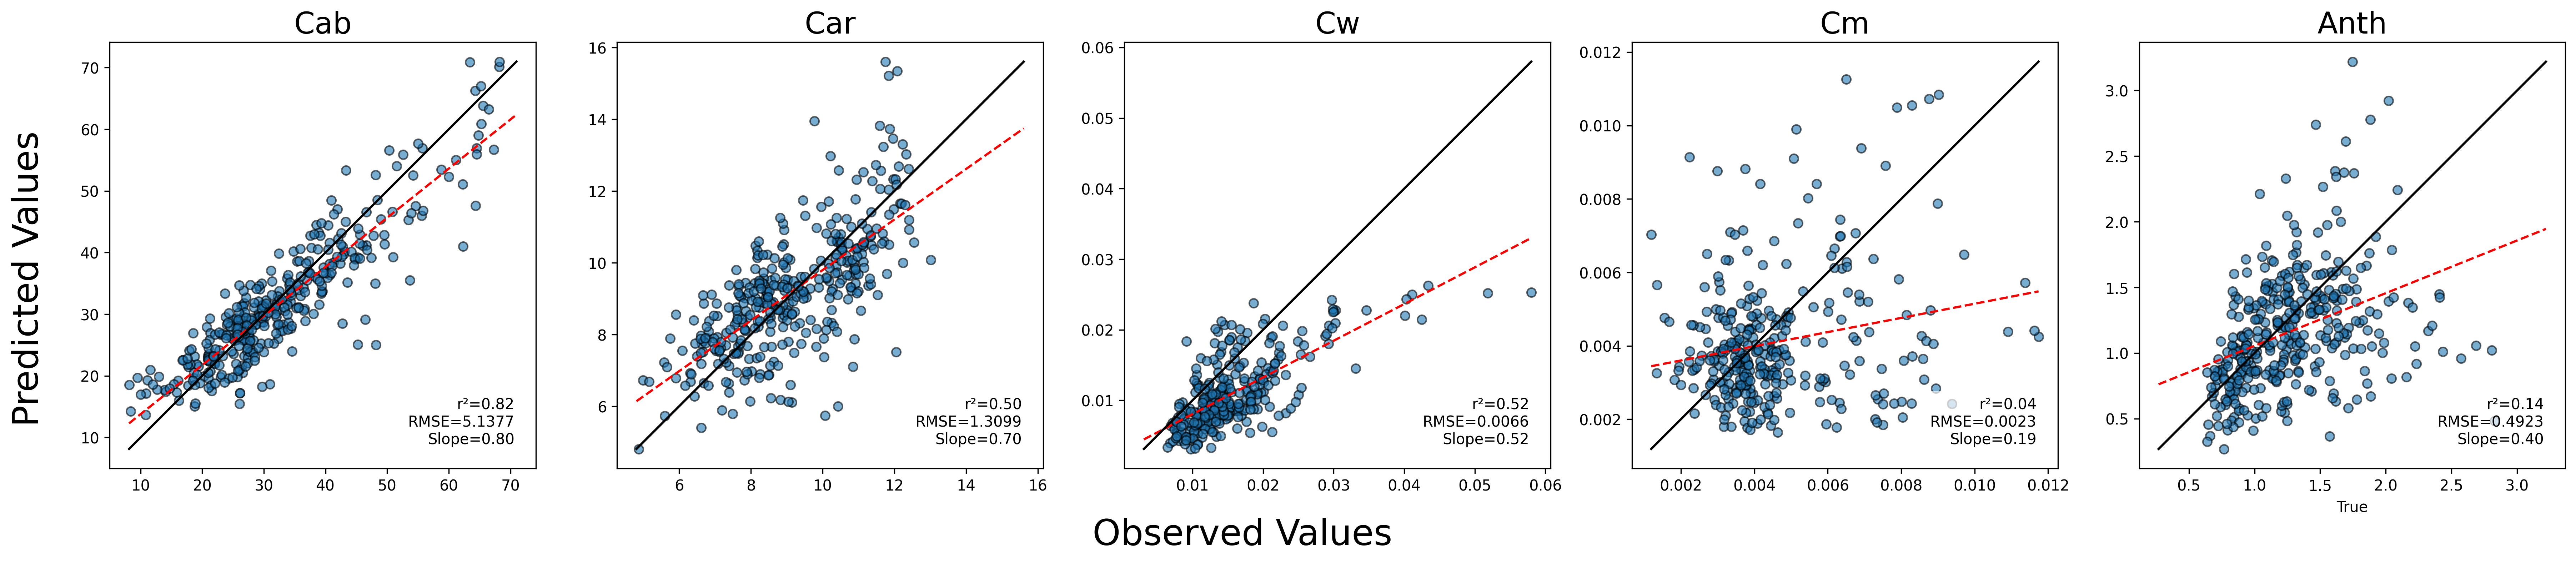

,Feature,r2,RMSE,Slope
0,Cab,0.820083,5.137665,0.796815
1,Car,0.495449,1.309929,0.704622
2,Cw,0.522365,0.006642,0.520021
3,Cm,0.041906,0.002303,0.193215
4,Anth,0.136285,0.492270,0.401241


In [21]:
plot_regressions(y_true,y_pred,ifgg_traits.columns)

# Two Use-Case Examples

This section demonstrates how to apply the inversion approaches introduced earlier to a fully simulated dataset - so users can get to know the functions without the direct need to first assemble an emperical dataset.

Both examples follow exactly the workflows described in the LUT and Inverse-Net sections; the aim here is simply to show how these methods behave when applied to synthetic data generated from known trait values.

The task is to predict leaf traits from reflectance spectra generated using PROSPECT-5. The same underlying simulation dataset is used to create both training and validation sets, allowing direct evaluation of retrieval accuracy.



## Use Case A: LUT-Based Inversion

This example applies the LUT method described earlier to a synthetic dataset. A LUT is created using user-specified parameter ranges, resolution, and optional noise. Because TorchRTM performs LUT generation and querying on GPU, the entire process—from table construction to inversion—runs efficiently even for high-resolution grids.

Once the LUT is built, the validation spectra are used as queries. For each query, the algorithm identifies the closest matches in the LUT using a chosen distance metric. As discussed in the LUT section, both the number of nearest neighbours and the distance order influence performance. Here, these choices are varied to explore sensitivity, and retrieval accuracy is assessed trait by trait.

This demonstrates how LUT-based inversion behaves when the spectra perfectly match the assumptions of the forward model—an idealised but informative benchmark.

## Use Case B: NN Inversion

The second example applies the Inverse-Net approach to the same synthetic dataset. The neural network learns to map spectra to traits directly, using the paired training examples. Unlike the LUT approach—which discretises the parameter space—the neural network produces continuous predictions and can generalise smoothly across trait ranges.

Evaluation follows the same metrics introduced earlier (R², RMSE, slope). Because the dataset is simulated, the retrieval task isolates the modelling behaviour of the network without confounding measurement noise or instrument artefacts.

This example illustrates how a lightweight, purely data-driven inversion behaves when trained and tested on noise-free data, and how its performance compares to the LUT baseline.

## Case A: Look up table


### Main function

In [ ]:
from torchrtm.utils.torch_utils import load_prosail_params
from torchrtm.leaf.prospect import prospect5b,prospectd
from torchrtm.utils.torchlut import Torchlut
from torchrtm.retrival.fastLUT import Torchlut_pred


### Application



---



In [ ]:

new_range = load_prosail_params()
new_range

,para,min,max
0,lai,1.000000,15.000
1,LIDFa,-1.000000,1.000
2,LIDFb,-1.000000,1.000
3,hspot (q also),0.000001,1.000
4,tts,0.000000,90.000
5,tto,0.000000,90.000
6,psi,0.000000,180.000
7,psoil,0.000000,1.000
8,N,1.000000,5.000
9,Cab,10.000000,200.000


We first use simulated spectra based on random traits as a test set.
The LUT can be created with a single line of code. The key parameters are table size, the number of candidate sets, and Gaussian noise standard deviation:


In [ ]:
new_range.iloc[10,2] = 20
new_range.iloc[14,2] = 5

In [ ]:
simulated_spectra, initial_traits = Torchlut ('prospectd', table_size = 500000, std = 0,para_addr=new_range)
test_spectra, test_traits = Torchlut ('prospectd', table_size = 1000, std = 0,para_addr=new_range)


prospectd


Processing Batches: 100%|██████████| 50/50 [00:20<00:00,  2.47it/s]


prospectd


Processing Batches: 100%|██████████| 1/1 [00:00<00:00, 19.00it/s]


In [ ]:
simulated_spectra = to_cuda(simulated_spectra)#.cpu()
initial_traits = to_cuda(initial_traits)#.cpu()
test_spectra = to_cuda(test_spectra)#.cpu()

Next, we use the validation spectra as a query and set the number of candidates to retrieve predictions from the test set (see the result in Figure 2A):

In [ ]:
_ = 9
k = 5
pred = Torchlut_pred(xb = simulated_spectra, xq=test_spectra, k=k,y=initial_traits,distance_order=_)
pred = to_np(pred)

Processing query blocks: 100%|██████████| 5/5 [00:32<00:00,  6.59s/it]


Optional: Choose the distance_order based on simulation data set


In [ ]:

for _ in range(10):
    pred = Torchlut_pred(xb = to_cuda(simulated_spectra), xq=to_cuda(test_spectra), k=k,y=to_cuda(initial_traits),distance_order=_)
    pred = to_np(pred)
    r2_list = []
    for ii in range(6):
        r2_list.append(r2_score((test_traits[:,ii]),pred[:,ii] ))
    print(_,r2_list)

Processing query blocks: 100%|██████████| 5/5 [00:19<00:00,  3.82s/it]


0 [0.6935237646102905, 0.22555488348007202, 0.04585903882980347, -0.1701500415802002, -0.08822715282440186, 0.18878358602523804]


Processing query blocks: 100%|██████████| 5/5 [00:20<00:00,  4.09s/it]


1 [0.9958235025405884, 0.9609468579292297, 0.2177448868751526, 0.9302429556846619, 0.9986238479614258, 0.9850683808326721]


Processing query blocks: 100%|██████████| 5/5 [00:01<00:00,  3.82it/s]


...

7 [0.9876877069473267, 0.9920507669448853, 0.6715073585510254, 0.9628844857215881, 0.9962971210479736, 0.9554027318954468]


Processing query blocks: 100%|██████████| 5/5 [00:41<00:00,  8.31s/it]


8 [0.986867368221283, 0.9916447997093201, 0.6727558374404907, 0.9627971053123474, 0.9959820508956909, 0.9538198709487915]


Processing query blocks: 100%|██████████| 5/5 [00:41<00:00,  8.33s/it]


9 [0.9864185452461243, 0.9916000962257385, 0.671188473701477, 0.9632535576820374, 0.9957965612411499, 0.9529203176498413]


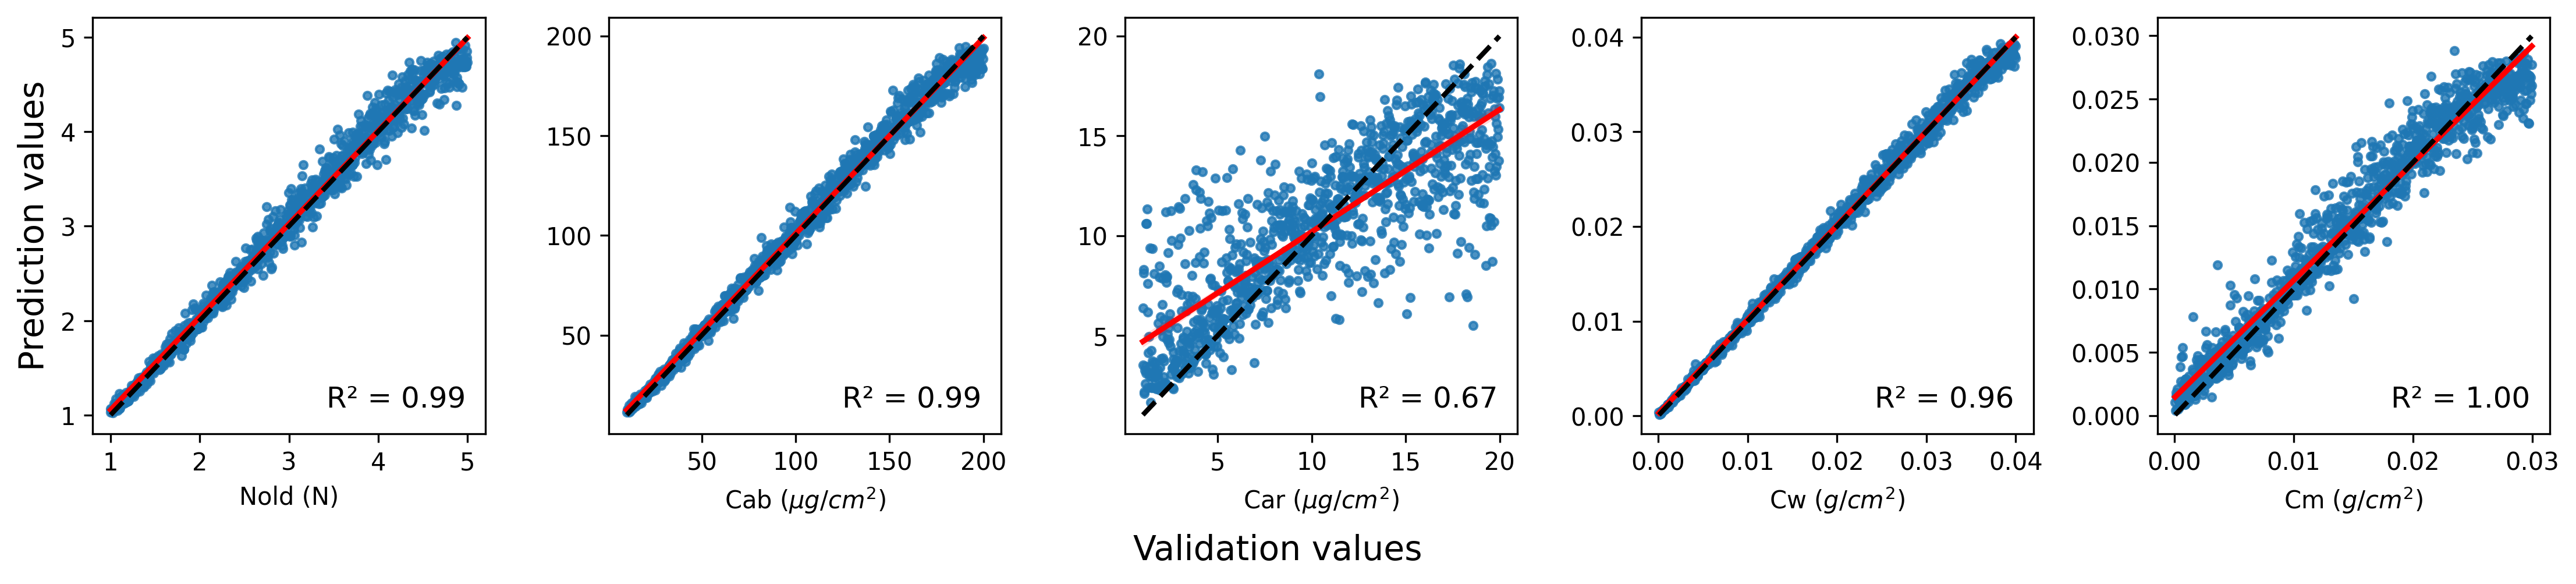

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Function to convert tensor to numpy if necessary (assuming to_np is already defined)
def to_np(tensor):
    return tensor if isinstance(tensor, np.ndarray) else tensor.numpy()
def to_np(x):
  return x.detach().cpu().numpy()
# Assuming pred and real_paras are pre-defined numpy arrays
# Convert prediction tensor to numpy

# R2 score calculation for each parameter
r2_list = []
for ii in range(6):
    r2_list.append(r2_score(test_traits[:, ii], pred[:, ii]))

# Set up plot parameters
labels = ['N', 'Car', 'Cab', 'Cbrown', 'Cw', 'Cm']  # Titles for subplots
units = Y_columns = [
    r'Nold (N)',                        # Leaf structure parameter (N)
    r'Cab ($\mu g/cm^2$)',              # Chlorophyll a+b content in ug/cm^2 (Cab)
    r'Car ($\mu g/cm^2$)',              # Carotenoids content in ug/cm^2 (Car)
    r'cbrown (arbitrary units)',        # Brown pigments content in arbitrary units (Cbrown)
    r'Cw ($g/cm^2$)',                   # Equivalent water thickness in g/cm^2 (Cw)
    r'Cm ($g/cm^2$)'                    # Leaf dry matter content in g/cm^2 - lma - (Cm)
]  # Labels for x-axis

# Create a figure with 1 row and 6 columns for subplots
fig, axes = plt.subplots(1, 5, figsize=(15,3.5), dpi=300)

# Plot each subplot
for i_index ,i in enumerate([0,1,2,4,5]):
    ax = axes[i_index]  # Current axis
    sns.regplot(x=validate_traits[:, i], y=pred[:, i], ax=ax, scatter_kws={'s': 10}, line_kws={'color': 'red'})

    # Add 1:1 line
    min_val = min(np.min(validate_traits[:, i]), np.min(pred[:, i]))
    max_val = max(np.max(validate_traits[:, i]), np.max(pred[:, i]))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
    ax.text(0.95, 0.05, f'R² = {r2_list[i_index]:.2f}', ha='right', va='bottom', transform=ax.transAxes, fontsize=12, color='black')


    # Set subplot title and x-axis label
    #ax.set_title(f'{labels[i]}')
    ax.set_xlabel(units[i])

    # Only add y-axis label to the first subplot (on the left)
    if i == 0:
        ax.set_ylabel('Prediction values', fontsize=14)

# Set the x-axis label for the entire figure
plt.figtext(0.5, 0.02, 'Validation values', ha='center', fontsize=14)

# Adjust layout for the overall plot
plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# Show the plot
plt.show()


This example shows how to integrate an RTM into a deep learning framework. Specifically, we use PROSPECTD from TorchRTM as the decoder and a simple multi-layer NN (Inverse-Net) as the encoder. Note that this does assume some familiarity with deep learning pipelines in PyTorch.

# Autoencoder Example: Using PROSPECT as a Physics-Informed Decoder


In a physics-informed autoencoder the structure enables:

* supervision on trait values (when reference traits are available),
* supervision on spectra (even without known traits),
* end-to-end differentiability,
* built-in physical consistency.

The example below follows this logic but applies it to a fully simulated dataset for clarity.




In this example, we demonstrate how to integrate the Radiative Transfer Model (RTM) into a deep learning structure. Specifically, we use Prospect5b from TorchRTM as the decoder and a simple ANN as the encoder.

### Main function

The main code for the fastcnn encoder



## Encoder

The encoder is a small, fully connected neural network defined through TorchRTM’s `Inverse_Net` builder. As stated before, it maps input spectra (∼2100 wavelengths) to a small vector of PROSPECT parameters. The architecture can be customised through the layer-size specification, but the core purpose remains the same:
learn trait values that, when fed into the RTM, reproduce the input spectra.

Becaued jointly with the decoder, it learns trait estimates that are consistent with the PROSPECT model for which the hope is that the prediction will therefore be more robust.



In [ ]:


# Define network architecture and move to device
layer_sizes = [2101, 444, 6]  # Input: spectral bands; Output: 7 RTM parameters
encoder = Inverse_Net(layer_sizes, use_attention=False, dropout_rate=0).to(device)  # Trait estimation network

## Simulated Dataset for Training and Testing

The dataset is generated using TorchRTM’s LUT-based spectral simulator, following the same procedure described in the earlier LUT section. Simulated traits and spectra are divided into training and validation subsets. This allows controlled testing of the autoencoder framework in an idealised setting where the forward model is known exactly.



In [ ]:


# Create dataset

train_dataset = SpectraDataset(simulated_spectra, initial_traits)
vali_dataset = SpectraDataset(test_spectra, test_traits)



To streamline training, we prepare a DataLoader with a specified batch size. The data loader could  serves as an efficient way to load and preprocess data in batches, facilitating the training of models.

In [ ]:
# DataLoader creation

batch_size = 500  # Adjust based on your requirements and memory constraints
shuffle = True  # Shuffle the data for training

# Example of iterating through the DataLoader

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)
vali_loader = DataLoader(vali_dataset, batch_size=batch_size, shuffle=shuffle)

Next, we define the decoder, utilizing the Prospect5 model from TorchRTM:

## Decoder

The decoder uses PROSPECT-5B implemented in TorchRTM. It converts predicted traits into leaf reflectance. As this model is wrapped in a PyTorch class, gradients propagate through every physical operation. Trait estimates that lead to inaccurately reconstructed spectra receive larger penalties, pulling the encoder toward physically correct solutions.

As said before, parameter normalisation ensures that predicted values remain within realistic ranges and in units valid for PROSPECT.




In [ ]:
from torchrtm.leaf.prospect import  prospectd,prospect5b
import torch.nn as nn

class ProspectDecoder(nn.Module):
    def __init__(self):
        super(ProspectDecoder, self).__init__()
    def forward(self, many_paras):
        real_paras = normalize_parameters(many_paras,fitting = False,param_type='prospect5b',use_torch = True,para_addr= new_range) #normlization_torch(many_paras, fitting=False)  # Normalize the input parameters
        refs = prospect5b(real_paras[:, 1:], real_paras[:, 0])    # Apply the prospect5 model
        return refs[0][:, :]  # Return the processed output excluding the last 50 elements
decoder = ProspectDecoder().to(device)  # Initialize the decoder and move it to the device



## Training Strategy

Below, training minimises a combined loss consisting of:

1. **Spectral reconstruction loss**:   Measures how closely the decoder reproduces the input spectrum.

2. **Trait consistency loss**:    Compares the predicted traits to the known traits (since this is a synthetic dataset).

Joint optimisation balances these two objectives. The reconstruction term pushes predictions toward spectra that satisfy physical radiative-transfer constraints, while the trait-loss term ensures accuracy relative to ground truth.

Mini-batches are processed through the encoder → decoder pipeline, and gradients update only the encoder's weights. The decoder remains a fixed physical model.



In [ ]:
criterion = torch.nn.MSELoss()  # Mean Squared Error loss function
optimizer = torch.optim.Adam(encoder.parameters(), lr=0.0001)  # Set learning rate at 0.001
num_epochs = 30  # Number of training epochs

for epoch in range(num_epochs):
    for batch_spectra, batch_traits in train_loader:
        batch_traits = normalize_parameters(to_cuda(batch_traits), fitting=True, param_type='prospect5b', use_torch=True)
        batch_spectra = to_cuda(batch_spectra)
        pred_traits = torch.sigmoid(encoder(batch_spectra))  # Predict the trats through the encoder
        simu_spectra = decoder(pred_traits)  # Reconstruct the spectra by predicted traits
        inversion_loss1 = criterion(simu_spectra, batch_spectra)  # Calculate the loss
        inversion_loss2 = criterion(pred_traits, batch_traits)
        optimizer.zero_grad()  # Reset gradients
        loss_t = inversion_loss1 + inversion_loss2 # Include additional custom loss terms if necessary
        loss_t.backward()  # Backpropagate the loss
        optimizer.step()  # Update the model parameters
    print('%s \'s epoch'%epoch)

0 's epoch
1 's epoch
2 's epoch
3 's epoch
4 's epoch
5 's epoch
6 's epoch
7 's epoch
8 's epoch
9 's epoch
10 's epoch
11 's epoch
12 's epoch
13 's epoch
14 's epoch
15 's epoch
16 's epoch
17 's epoch
18 's epoch
19 's epoch
20 's epoch
21 's epoch
22 's epoch
23 's epoch
24 's epoch
25 's epoch
26 's epoch
27 's epoch
28 's epoch
29 's epoch


In [ ]:
pred = torch.sigmoid(encoder(test_spectra))


## Model Inference and Evaluation

After training, the encoder predicts traits for the validation spectra. These predictions are then converted back into physical units. Retrieval accuracy is evaluated using standard regression diagnostics:

* R² for each trait,
* RMSE,
* slope relative to the 1:1 line.

Because the dataset is simulated, this provides an upper bound on achievable performance and a clear demonstration of how well the autoencoder can learn PROSPECT-consistent trait representations.



In [ ]:
import time
start_time = time.time()  # ⏱️ start timer

encoder.eval()
pred_vali = torch.sigmoid(encoder(to_cuda(test_spectra)))
# Print total runtime
end_time = time.time()  # ⏱️ end timer
print(f"Validation runtime: {end_time - start_time:.3f} seconds")


Validation runtime: 0.025 seconds


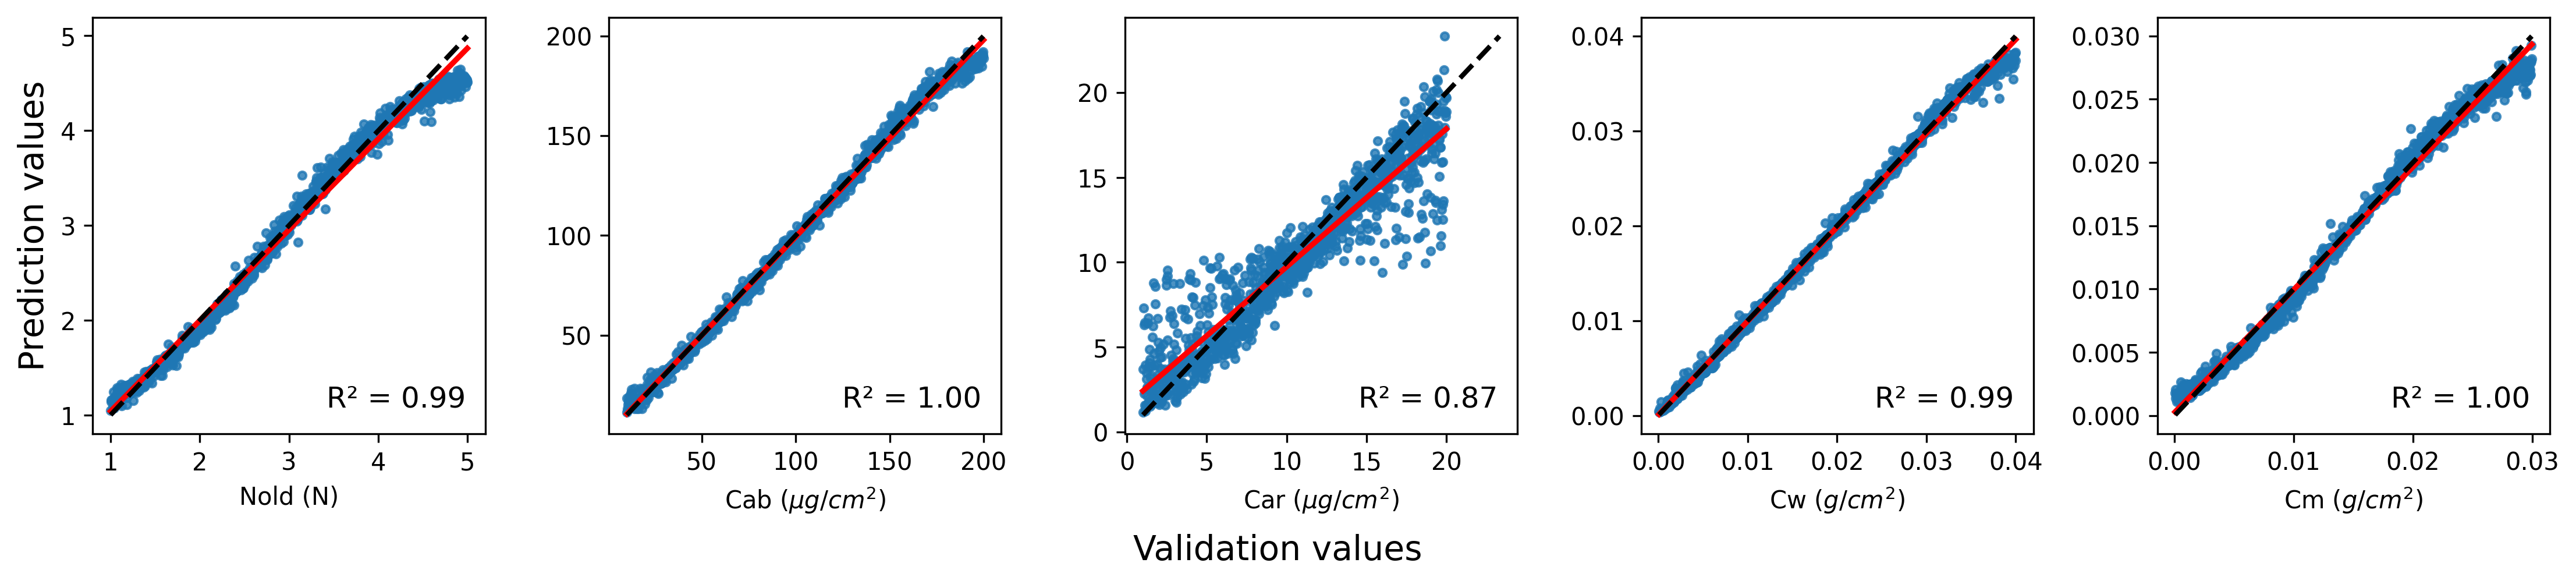

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Function to convert tensor to numpy if necessary (assuming to_np is already defined)
def to_np(tensor):
    return tensor if isinstance(tensor, np.ndarray) else tensor.numpy()
def to_np(x):
  return x.detach().cpu().numpy()
# Assuming pred and real_paras are pre-defined numpy arrays
# Convert prediction tensor to numpy
pred = to_np(normalize_parameters(pred_vali, fitting=False,param_type='prospect5b') )
real_paras = (test_traits)

# R2 score calculation for each parameter
r2_list = []
for ii in range(6):
    r2_list.append(r2_score(real_paras[:, ii], pred[:, ii]))

# Set up plot parameters
labels = ['N', 'Car', 'Cab', 'Cbrown', 'Cw', 'Cm']  # Titles for subplots
units = Y_columns = [
    r'Nold (N)',                        # Leaf structure parameter (N)
    r'Cab ($\mu g/cm^2$)',              # Chlorophyll a+b content in ug/cm^2 (Cab)
    r'Car ($\mu g/cm^2$)',              # Carotenoids content in ug/cm^2 (Car)
    r'cbrown (arbitrary units)',        # Brown pigments content in arbitrary units (Cbrown)
    r'Cw ($g/cm^2$)',                   # Equivalent water thickness in g/cm^2 (Cw)
    r'Cm ($g/cm^2$)'                    # Leaf dry matter content in g/cm^2 - lma - (Cm)
]  # Labels for x-axis

# Create a figure with 1 row and 6 columns for subplots
fig, axes = plt.subplots(1, 5, figsize=(15,3.5), dpi=300)

# Plot each subplot
for i_index ,i in enumerate([0,1,2,4,5]):
    ax = axes[i_index]  # Current axis
    sns.regplot(x=real_paras[:, i], y=pred[:, i], ax=ax, scatter_kws={'s': 10}, line_kws={'color': 'red'})

    # Add 1:1 line
    min_val = min(np.min(real_paras[:, i]), np.min(pred[:, i]))
    max_val = max(np.max(real_paras[:, i]), np.max(pred[:, i]))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
    ax.text(0.95, 0.05, f'R² = {r2_list[i_index]:.2f}', ha='right', va='bottom', transform=ax.transAxes, fontsize=12, color='black')


    # Set subplot title and x-axis label
    #ax.set_title(f'{labels[i]}')
    ax.set_xlabel(units[i])

    # Only add y-axis label to the first subplot (on the left)
    if i == 0:
        ax.set_ylabel('Prediction values', fontsize=14)

# Set the x-axis label for the entire figure
plt.figtext(0.5, 0.02, 'Validation values', ha='center', fontsize=14)

# Adjust layout for the overall plot
plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# Show the plot
plt.show()
